## Quantum Run - Maxcut GSet

We use polar coordinates for opt, mf density = Tensor_prod($\rho_i$), each density = 1/2 (I + $x_i \sigma_x + z_i \sigma_z$)

$x_i = R_i \sin{\theta_i} \ $
$z_i = R_i \cos{\theta_i}$

Try with both Adam, SGD and RMSprop, right now test with same params as vanilla run for direct performance benchmarking, hyperparams are already defined in the very beginning.

In [1]:
from pathlib import Path
import time
import math

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


In [3]:
DATA_GSET_DIR = Path("../data-gset")

VANILLA_RESULTS_PATH = Path("naive_vanilla_fem_G1-G54_full_results.csv")
VALIDATION_PATH = Path("gset_validation.txt")

OUTPUT_DIR = Path("qefem_v1_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

### Use same settings as naive vanilla for gset maxcut

In [4]:
N_STEPS = 1000
REPLICAS = 128
SEED = 0
PRINT_EVERY = 100

DTYPE = torch.float32

BETA_MIN = 2.0
BETA_MAX = 12500.0
BETA_SCHEDULE_KIND = "linear"

LR = 0.01
OPTIMIZER_NAME = "Adam"

For now just do linear gamma, later try with poly/ exponent

In [5]:
# R is Bloch length. It must start small.
R_INIT = 1e-2

# theta starts near pi/2 so rx is initially active and rz is initially small.
THETA_CENTER = math.pi / 2
THETA_NOISE = 1e-3

# Gamma sanity test and real QEFEM schedule.
GAMMA_ZERO = 0.0

GAMMA_MAX = 1.0
GAMMA_MIN = 0.0
GAMMA_SCHEDULE_KIND = "linear"


print("\nGlobal settings:")
print("N_STEPS:", N_STEPS)
print("REPLICAS:", REPLICAS)
print("SEED:", SEED)
print("BETA:", BETA_MIN, "->", BETA_MAX)
print("LR:", LR)
print("R_INIT:", R_INIT)
print("THETA_CENTER:", THETA_CENTER)
print("THETA_NOISE:", THETA_NOISE)
print("GAMMA full schedule:", GAMMA_MAX, "->", GAMMA_MIN)


Global settings:
N_STEPS: 1000
REPLICAS: 128
SEED: 0
BETA: 2.0 -> 12500.0
LR: 0.01
R_INIT: 0.01
THETA_CENTER: 1.5707963267948966
THETA_NOISE: 0.001
GAMMA full schedule: 1.0 -> 0.0


#### Load Vanilla FEM baseline for comparison!

In [6]:
if not VANILLA_RESULTS_PATH.exists():
    raise FileNotFoundError(
        f"Could not find vanilla baseline CSV:\n{VANILLA_RESULTS_PATH.resolve()}\n\n"
        "Place naive_vanilla_fem_G1-G54_full_results.csv in the same directory as this notebook."
    )

vanilla_results_df = pd.read_csv(VANILLA_RESULTS_PATH)

print("Loaded vanilla baseline:")
print("Rows:", len(vanilla_results_df))
print("Columns:")
print(list(vanilla_results_df.columns))

Loaded vanilla baseline:
Rows: 54
Columns:
['batch', 'g_index', 'instance', 'N', 'edges', 'best_known_cut', 'vanilla_fem_best_cut', 'gap', 'accuracy', 'percent_accuracy', 'runtime_sec', 'best_replica', 'R', 'N_steps', 'beta_min', 'beta_max', 'schedule_kind', 'lr', 'seed']


In [7]:
display(vanilla_results_df.head())

,batch,g_index,instance,N,edges,best_known_cut,vanilla_fem_best_cut,gap,accuracy,percent_accuracy,runtime_sec,best_replica,R,N_steps,beta_min,beta_max,schedule_kind,lr,seed
0,1,1,G1,800,19176,11624,11446.0,178.0,0.984687,98.468685,4.368305,10,128,1000,2.0,12500.0,linear,0.01,0
1,1,2,G2,800,19176,11620,11435.0,185.0,0.984079,98.407917,4.299664,55,128,1000,2.0,12500.0,linear,0.01,0
2,1,3,G3,800,19176,11622,11443.0,179.0,0.984598,98.459818,4.356321,14,128,1000,2.0,12500.0,linear,0.01,0
3,1,4,G4,800,19176,11646,11503.0,143.0,0.987721,98.772111,4.275009,75,128,1000,2.0,12500.0,linear,0.01,0
4,1,5,G5,800,19176,11631,11450.0,181.0,0.984438,98.443814,4.161925,106,128,1000,2.0,12500.0,linear,0.01,0


In [8]:
vanilla_compare_df = vanilla_results_df.copy()

# Keep only the comparison columns we actually need.
vanilla_compare_df = vanilla_compare_df[
    [
        "instance",
        "N",
        "edges",
        "best_known_cut",
        "vanilla_fem_best_cut",
        "gap",
        "accuracy",
        "percent_accuracy",
        "runtime_sec",
    ]
].rename(
    columns={
        "N": "nodes",
        "best_known_cut": "best_value",
        "vanilla_fem_best_cut": "vanilla_cut",
        "gap": "vanilla_gap",
        "accuracy": "vanilla_accuracy",
        "percent_accuracy": "vanilla_percent_accuracy",
        "runtime_sec": "vanilla_tts_seconds",
    }
)

vanilla_compare_df["instance"] = vanilla_compare_df["instance"].astype(str)

print("\nStandardized vanilla comparison dataframe:")


Standardized vanilla comparison dataframe:


In [9]:
display(vanilla_compare_df.head())

,instance,nodes,edges,best_value,vanilla_cut,vanilla_gap,vanilla_accuracy,vanilla_percent_accuracy,vanilla_tts_seconds
0,G1,800,19176,11624,11446.0,178.0,0.984687,98.468685,4.368305
1,G2,800,19176,11620,11435.0,185.0,0.984079,98.407917,4.299664
2,G3,800,19176,11622,11443.0,179.0,0.984598,98.459818,4.356321
3,G4,800,19176,11646,11503.0,143.0,0.987721,98.772111,4.275009
4,G5,800,19176,11631,11450.0,181.0,0.984438,98.443814,4.161925


### GSet historical validation table

In [10]:
if not VALIDATION_PATH.exists():
    raise FileNotFoundError(
        f"Could not find validation file:\n{VALIDATION_PATH.resolve()}\n\n"
        "Place gset_validation.txt in the same directory as this notebook."
    )

records = []

with VALIDATION_PATH.open("r") as f:
    for line_no, line in enumerate(f, start=1):
        line = line.strip()

        if not line or line.startswith("#"):
            continue

        parts = line.split()

        if len(parts) != 2:
            raise ValueError(
                f"Bad line {line_no}: {line!r}. "
                "Expected format: <gset_index> <best_known_cut>"
            )

        g_index = int(parts[0])
        best_known_cut = int(parts[1])

        records.append(
            {
                "g_index": g_index,
                "instance": f"G{g_index}",
                "best_known_cut": best_known_cut,
            }
        )

gset_all_best_df = (
    pd.DataFrame(records)
    .sort_values("g_index")
    .reset_index(drop=True)
)

GSET_BEST_KNOWN_ALL = dict(
    zip(gset_all_best_df["instance"], gset_all_best_df["best_known_cut"])
)

print("\nLoaded Gset validation:")
print("Rows:", len(gset_all_best_df))
display(gset_all_best_df.head(10))


Loaded Gset validation:
Rows: 71


,g_index,instance,best_known_cut
0,1,G1,11624
1,2,G2,11620
2,3,G3,11622
3,4,G4,11646
4,5,G5,11631
5,6,G6,2178
6,7,G7,2006
7,8,G8,2005
8,9,G9,2054
9,10,G10,2000


In [11]:
merged_vanilla_validation_check = vanilla_compare_df.merge(
    gset_all_best_df[["instance", "best_known_cut"]],
    on="instance",
    how="left",
)

bad_rows = merged_vanilla_validation_check[
    merged_vanilla_validation_check["best_value"]
    != merged_vanilla_validation_check["best_known_cut"]
]

if len(bad_rows) > 0:
    print("\nWARNING: Vanilla CSV best-known values do not match gset_validation.txt:")
    display(bad_rows)
else:
    print("\nSanity check passed:")
    print("Vanilla CSV best-known values match gset_validation.txt.")


Sanity check passed:
Vanilla CSV best-known values match gset_validation.txt.


In [12]:
# ----------------------------
# Active benchmark scopes
# ----------------------------
GSET_G1_G10 = [f"G{i}" for i in range(1, 11)]
GSET_G1_G54 = [f"G{i}" for i in range(1, 55)]

print("\nBenchmark scopes:")
print("G1-G10:", GSET_G1_G10)


Benchmark scopes:
G1-G10: ['G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'G10']


#### Define Gset Batch partitions

In [27]:
# ============================================================
# Cell 3: Define Gset benchmark batches
# ============================================================

GSET_BATCHES = {
    1: [f"G{i}" for i in range(1, 11)],    # G1-G10
    2: [f"G{i}" for i in range(11, 14)],   # G11-G13
    3: [f"G{i}" for i in range(14, 22)],   # G14-G21
    4: [f"G{i}" for i in range(22, 32)],   # G22-G31
    5: [f"G{i}" for i in range(32, 35)],   # G32-G34
    6: [f"G{i}" for i in range(35, 43)],   # G35-G42
    7: [f"G{i}" for i in range(43, 48)],   # G43-G47
    8: [f"G{i}" for i in range(48, 51)],   # G48-G50
    9: [f"G{i}" for i in range(51, 55)],   # G51-G54
}

print("Gset benchmark batches:")
for batch_id, instances in GSET_BATCHES.items():
    print(
        f"Batch {batch_id}: "
        f"{instances[0]}-{instances[-1]} | "
        f"{len(instances)} instances | "
        f"{instances}"
    )

Gset benchmark batches:
Batch 1: G1-G10 | 10 instances | ['G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'G10']
Batch 2: G11-G13 | 3 instances | ['G11', 'G12', 'G13']
Batch 3: G14-G21 | 8 instances | ['G14', 'G15', 'G16', 'G17', 'G18', 'G19', 'G20', 'G21']
Batch 4: G22-G31 | 10 instances | ['G22', 'G23', 'G24', 'G25', 'G26', 'G27', 'G28', 'G29', 'G30', 'G31']
Batch 5: G32-G34 | 3 instances | ['G32', 'G33', 'G34']
Batch 6: G35-G42 | 8 instances | ['G35', 'G36', 'G37', 'G38', 'G39', 'G40', 'G41', 'G42']
Batch 7: G43-G47 | 5 instances | ['G43', 'G44', 'G45', 'G46', 'G47']
Batch 8: G48-G50 | 3 instances | ['G48', 'G49', 'G50']
Batch 9: G51-G54 | 4 instances | ['G51', 'G52', 'G53', 'G54']


In [28]:
# ----------------------------
# Flatten full benchmark list
# ----------------------------
GSET_ALL_INSTANCES = []

for batch_id in sorted(GSET_BATCHES.keys()):
    GSET_ALL_INSTANCES.extend(GSET_BATCHES[batch_id])

print("\nTotal Gset instances in benchmark:", len(GSET_ALL_INSTANCES))
print("First instance:", GSET_ALL_INSTANCES[0])
print("Last instance:", GSET_ALL_INSTANCES[-1])


Total Gset instances in benchmark: 54
First instance: G1
Last instance: G54


In [29]:
# ----------------------------
# Sanity checks against validation and vanilla baseline
# ----------------------------
missing_from_validation = [
    instance for instance in GSET_ALL_INSTANCES
    if instance not in GSET_BEST_KNOWN_ALL
]

missing_from_vanilla = [
    instance for instance in GSET_ALL_INSTANCES
    if instance not in set(vanilla_compare_df["instance"])
]

if missing_from_validation:
    raise ValueError(
        "These benchmark instances are missing from gset_validation.txt:\n"
        f"{missing_from_validation}"
    )

if missing_from_vanilla:
    raise ValueError(
        "These benchmark instances are missing from vanilla baseline CSV:\n"
        f"{missing_from_vanilla}"
    )

print("\nSanity check passed:")
print("All G1-G54 instances exist in validation file and vanilla baseline CSV.")


# ----------------------------
# Useful scopes for later cells
# ----------------------------
GSET_SANITY_INSTANCE = "G1"
GSET_FIRST_SWEEP = GSET_BATCHES[1]
GSET_PROBLEM_BATCH = GSET_BATCHES[6]

print("\nUseful scopes:")
print("Single sanity instance:", GSET_SANITY_INSTANCE)
print("First sweep:", GSET_FIRST_SWEEP)
print("Problem batch:", GSET_PROBLEM_BATCH)


Sanity check passed:
All G1-G54 instances exist in validation file and vanilla baseline CSV.

Useful scopes:
Single sanity instance: G1
First sweep: ['G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'G10']
Problem batch: ['G35', 'G36', 'G37', 'G38', 'G39', 'G40', 'G41', 'G42']


### Loading the adjacency matrix : 
First test with G1

In [30]:
def load_gset_dense(path, device=device, dtype=DTYPE, index_start=1):

    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Could not find Gset file:\n{path.resolve()}")

    with path.open("r") as f:
        first = f.readline().strip().split()

        if len(first) != 2:
            raise ValueError(f"Bad first line in {path}: {first}")

        n, m = map(int, first)

        # Fill on CPU first. MPS scalar writes are slow and petty.
        W_cpu = torch.zeros((n, n), dtype=dtype, device="cpu")

        edge_count = 0
        total_weight_edges = 0.0
        positive_edges = 0
        negative_edges = 0
        zero_edges = 0
        self_edges = 0

        for line_id, line in enumerate(f, start=2):
            parts = line.strip().split()

            if not parts:
                continue

            if len(parts) != 3:
                raise ValueError(
                    f"Bad line {line_id} in {path}: {line!r}. "
                    "Expected format: i j w"
                )

            i_raw, j_raw, w_raw = parts

            i = int(i_raw) - index_start
            j = int(j_raw) - index_start
            w = float(w_raw)

            if not (0 <= i < n and 0 <= j < n):
                raise IndexError(
                    f"Node index out of range at line {line_id}: "
                    f"i={i}, j={j}, n={n}"
                )

            if i == j:
                self_edges += 1

            if w > 0:
                positive_edges += 1
            elif w < 0:
                negative_edges += 1
            else:
                zero_edges += 1

            W_cpu[i, j] = w
            W_cpu[j, i] = w

            edge_count += 1
            total_weight_edges += w

    W = W_cpu.to(device=device, dtype=dtype)

    with torch.no_grad():
        diag = torch.diag(W)
        W_sum = float(W.sum().detach().cpu())
        symmetric = bool(torch.allclose(W, W.T))
        diag_zero = bool(torch.allclose(diag, torch.zeros_like(diag)))
        nonzero_directed_entries = int(torch.count_nonzero(W).detach().cpu())

    info = {
        "path": str(path),
        "n": n,
        "m_header": m,
        "m_loaded": edge_count,
        "total_weight_edges": total_weight_edges,
        "positive_edges": positive_edges,
        "negative_edges": negative_edges,
        "zero_edges": zero_edges,
        "self_edges": self_edges,
        "W_sum": W_sum,
        "nonzero_directed_entries": nonzero_directed_entries,
        "expected_directed_entries": 2 * edge_count,
        "symmetric": symmetric,
        "diag_zero": diag_zero,
        "device": str(W.device),
        "dtype": str(W.dtype),
    }

    if edge_count != m:
        print(
            "WARNING: loaded edge count does not match header:",
            edge_count,
            "!=",
            m,
        )

    if not symmetric:
        print("WARNING: W is not symmetric. That is not cute.")

    if not diag_zero:
        print("WARNING: W diagonal is not zero.")

    return W, info

In [31]:
g1_path = DATA_GSET_DIR / "G1"

print("G1 path:", g1_path.resolve())
print("G1 exists?", g1_path.exists())

G1 path: /Users/ronit/Desktop/QeFEM/main/data-gset/G1
G1 exists? True


In [32]:
instance = GSET_SANITY_INSTANCE   # "G1"
gset_path = DATA_GSET_DIR / instance

print("Loading instance:", instance)
print("Path:", gset_path.resolve())


# ----------------------------
# Load dense W
# ----------------------------
W, graph_info = load_gset_dense(
    gset_path,
    device=device,
    dtype=DTYPE,
    index_start=1,
)

N = W.shape[0]
best_known = GSET_BEST_KNOWN_ALL[instance]


# ----------------------------
# Print graph metadata
# ----------------------------
print("\nGraph info:")
for key, value in graph_info.items():
    print(f"{key}: {value}")

print("\nBenchmark info:")
print("Instance:", instance)
print("N:", N)
print("Best-known cut:", best_known)

Loading instance: G1
Path: /Users/ronit/Desktop/QeFEM/main/data-gset/G1

Graph info:
path: ../data-gset/G1
n: 800
m_header: 19176
m_loaded: 19176
total_weight_edges: 19176.0
positive_edges: 19176
negative_edges: 0
zero_edges: 0
self_edges: 0
W_sum: 38352.0
nonzero_directed_entries: 38352
expected_directed_entries: 38352
symmetric: True
diag_zero: True
device: mps:0
dtype: torch.float32

Benchmark info:
Instance: G1
N: 800
Best-known cut: 11624


In [33]:
print("\nGraph info:")
for key, value in graph_info.items():
    print(f"{key}: {value}")

print("\nBenchmark info:")
print("Instance:", instance)
print("N:", N)
print("Best-known cut:", best_known)


# ----------------------------
# Hard sanity assertions
# ----------------------------
assert graph_info["m_loaded"] == graph_info["m_header"], (
    "Loaded edge count does not match header. "
    "Tiny loader goblin detected."
)

assert graph_info["symmetric"] is True, "W must be symmetric."

assert graph_info["diag_zero"] is True, "W diagonal must be zero."

assert graph_info["nonzero_directed_entries"] == graph_info["expected_directed_entries"], (
    "Directed nonzero entries should be exactly 2 * edge_count "
    "for a symmetric undirected graph."
)

assert instance in vanilla_compare_df["instance"].values, (
    f"{instance} missing from vanilla baseline dataframe."
)


# ----------------------------
# Pull vanilla baseline for this instance
# ----------------------------
vanilla_row = vanilla_compare_df.query("instance == @instance").iloc[0]

print("\nVanilla baseline for this instance:")
print("Vanilla cut:", vanilla_row["vanilla_cut"])
print("Vanilla best-known:", vanilla_row["best_value"])
print("Vanilla gap:", vanilla_row["vanilla_gap"])
print("Vanilla accuracy %:", vanilla_row["vanilla_percent_accuracy"])
print("Vanilla runtime sec:", vanilla_row["vanilla_tts_seconds"])


Graph info:
path: ../data-gset/G1
n: 800
m_header: 19176
m_loaded: 19176
total_weight_edges: 19176.0
positive_edges: 19176
negative_edges: 0
zero_edges: 0
self_edges: 0
W_sum: 38352.0
nonzero_directed_entries: 38352
expected_directed_entries: 38352
symmetric: True
diag_zero: True
device: mps:0
dtype: torch.float32

Benchmark info:
Instance: G1
N: 800
Best-known cut: 11624

Vanilla baseline for this instance:
Vanilla cut: 11446.0
Vanilla best-known: 11624
Vanilla gap: 178.0
Vanilla accuracy %: 98.46868547832072
Vanilla runtime sec: 4.368304967880249


### Define Cut function

In [34]:
def discrete_cut(W, spins):

    single_input = False

    if spins.dim() == 1:
        spins = spins.unsqueeze(0)
        single_input = True

    spins = spins.to(device=W.device, dtype=W.dtype)

    quad = torch.einsum("ri,ij,rj->r", spins, W, spins)
    cut = 0.25 * (W.sum() - quad)

    if single_input:
        return cut.squeeze(0)

    return cut

### Define the Bloch parameterization

In [35]:
def bloch_from_raw(raw_R, theta):

    # R = sigmoid(raw_R) ---> trainable latent raw_R like fields give Bloch radius
    
    R = torch.sigmoid(raw_R)

    rx = R * torch.sin(theta)
    rz = R * torch.cos(theta)

    return R, rx, rz


def raw_R_from_init_value(R_init, device=device, dtype=DTYPE):
    """
    Convert a desired initial Bloch radius R_init into raw_R
    such that sigmoid(raw_R) = R_init.
    """
    
    # raw_R = logit(R) ---> opposite of previous function
    
    if not (0.0 < R_init < 1.0):
        raise ValueError("R_init must be strictly between 0 and 1. Humanity survives by constraints.")

    R_init_tensor = torch.tensor(R_init, device=device, dtype=dtype)
    raw_value = torch.logit(R_init_tensor)

    return raw_value

In [36]:
raw_R_test_value = raw_R_from_init_value(R_INIT)

raw_R_test = raw_R_test_value * torch.ones(
    REPLICAS,
    N,
    device=device,
    dtype=DTYPE,
)

theta_test = THETA_CENTER + THETA_NOISE * torch.randn(
    REPLICAS,
    N,
    device=device,
    dtype=DTYPE,
)

R_test, rx_test, rz_test = bloch_from_raw(raw_R_test, theta_test)

print("raw_R init value:", float(raw_R_test_value.detach().cpu()))
print("R_test shape:", R_test.shape)
print("rx_test shape:", rx_test.shape)
print("rz_test shape:", rz_test.shape)

print("\nInitial Bloch stats:")
print("R mean:", float(R_test.mean().detach().cpu()))
print("R min:", float(R_test.min().detach().cpu()))
print("R max:", float(R_test.max().detach().cpu()))

print("\nInitial component stats:")
print("rx mean:", float(rx_test.mean().detach().cpu()))
print("rx abs mean:", float(rx_test.abs().mean().detach().cpu()))
print("rz mean:", float(rz_test.mean().detach().cpu()))
print("rz abs mean:", float(rz_test.abs().mean().detach().cpu()))

# Since theta starts near pi/2:
# rx should be close to R_INIT, rz should be tiny.
assert torch.all(R_test > 0), "R must be positive."
assert torch.all(R_test < 1), "R must be less than 1."

raw_R init value: -4.595119476318359
R_test shape: torch.Size([128, 800])
rx_test shape: torch.Size([128, 800])
rz_test shape: torch.Size([128, 800])

Initial Bloch stats:
R mean: 0.01000000350177288
R min: 0.01000000350177288
R max: 0.01000000350177288

Initial component stats:
rx mean: 0.009999998845160007
rx abs mean: 0.009999998845160007
rz mean: -1.8704774618072406e-08
rz abs mean: 7.945852303237189e-06


### Define Quantum entropy

In [37]:
def quantum_entropy_from_R(R, eps=1e-12):

    single_input = False

    if R.dim() == 1:
        R = R.unsqueeze(0)
        single_input = True

    R = R.clamp(eps, 1.0 - eps)

    lambda_plus = 0.5 * (1.0 + R)
    lambda_minus = 0.5 * (1.0 - R)

    entropy_per_spin = -(
        lambda_plus * torch.log(lambda_plus)
        + lambda_minus * torch.log(lambda_minus)
    )

    entropy = entropy_per_spin.sum(dim=1)

    if single_input:
        return entropy.squeeze(0)

    return entropy

In [38]:
S_test = quantum_entropy_from_R(R_test)

print("Entropy shape:", S_test.shape)
print("Entropy mean:", float(S_test.mean().detach().cpu()))
print("Entropy min:", float(S_test.min().detach().cpu()))
print("Entropy max:", float(S_test.max().detach().cpu()))

# For R near 0, each qubit has entropy close to log(2).
max_entropy_per_replica = N * math.log(2.0)

print("\nTheoretical max entropy per replica, N log 2:")
print(max_entropy_per_replica)

print("\nEntropy mean / max entropy:")
print(float(S_test.mean().detach().cpu() / max_entropy_per_replica))

# R_INIT = 1e-2 should give entropy very close to N log 2.
assert torch.all(S_test > 0), "Entropy should be positive."
assert torch.all(S_test <= max_entropy_per_replica + 1e-3), (
    "Entropy exceeded N log 2. Entropy goblin detected."
)

Entropy shape: torch.Size([128])
Entropy mean: 554.4776611328125
Entropy min: 554.4776611328125
Entropy max: 554.4776611328125

Theoretical max entropy per replica, N log 2:
554.5177444479563

Entropy mean / max entropy:
0.9999276995658875


### Expected Cut

In [39]:
def quantum_expected_cut(W, rz):
    
    single_input = False

    if rz.dim() == 1:
        rz = rz.unsqueeze(0)
        single_input = True

    rz = rz.to(device=W.device, dtype=W.dtype)

    quad = torch.einsum("ri,ij,rj->r", rz, W, rz)
    expected_cut = 0.25 * (W.sum() - quad)

    if single_input:
        return expected_cut.squeeze(0)

    return expected_cut

In [41]:
expected_cut_test = quantum_expected_cut(W, rz_test)

print("Expected cut shape:", expected_cut_test.shape)
print("Expected cut mean:", float(expected_cut_test.mean().detach().cpu()))
print("Expected cut min:", float(expected_cut_test.min().detach().cpu()))
print("Expected cut max:", float(expected_cut_test.max().detach().cpu()))

print("\nBest-known cut:", best_known)
print("Vanilla FEM cut:", vanilla_row["vanilla_cut"])

# Since rz starts close to 0, expected cut should be close to W.sum()/4.
soft_uniform_cut = 0.25 * float(W.sum().detach().cpu())

print("\nSoft uniform reference W.sum()/4:")
print(soft_uniform_cut)

print("\nMean expected cut - W.sum()/4:")       #should be 0 because E[C] = 1/4 (\sum W_ij - z^T W z)..... 
# z (init) -->0 thus diff => E[C] - 0.25 \sum W = 0 is expected...

print(float(expected_cut_test.mean().detach().cpu()) - soft_uniform_cut)

Expected cut shape: torch.Size([128])
Expected cut mean: 9588.0
Expected cut min: 9588.0
Expected cut max: 9588.0

Best-known cut: 11624
Vanilla FEM cut: 11446.0

Soft uniform reference W.sum()/4:
9588.0

Mean expected cut - W.sum()/4:
0.0


### Build the Transverse Mixer/ Driver

In [44]:
def transverse_driver_energy(rx, gamma):

    single_input = False

    if rx.dim() == 1:
        rx = rx.unsqueeze(0)
        single_input = True

    gamma = torch.as_tensor(
        gamma,
        device=rx.device,
        dtype=rx.dtype,
    )

    driver_energy = -gamma * rx.sum(dim=1)

    if single_input:
        return driver_energy.squeeze(0)

    return driver_energy

In [45]:
driver_zero_test = transverse_driver_energy(rx_test, gamma=0.0)
driver_full_test = transverse_driver_energy(rx_test, gamma=GAMMA_MAX)

print("Driver energy shape:", driver_full_test.shape)

print("\nGamma = 0 driver stats:")
print("mean:", float(driver_zero_test.mean().detach().cpu()))
print("min:", float(driver_zero_test.min().detach().cpu()))
print("max:", float(driver_zero_test.max().detach().cpu()))

print("\nGamma = 1 driver stats:")
print("mean:", float(driver_full_test.mean().detach().cpu()))
print("min:", float(driver_full_test.min().detach().cpu()))
print("max:", float(driver_full_test.max().detach().cpu()))

# With theta near pi/2 and R_INIT=1e-2:
# rx.sum() should be close to N * R_INIT.
expected_initial_driver = -GAMMA_MAX * N * R_INIT

print("\nExpected rough initial driver energy for gamma=1:")
print(expected_initial_driver)

print("\nObserved mean driver energy for gamma=1:")
print(float(driver_full_test.mean().detach().cpu()))

Driver energy shape: torch.Size([128])

Gamma = 0 driver stats:
mean: 0.0
min: -0.0
max: -0.0

Gamma = 1 driver stats:
mean: -7.999999046325684
min: -7.999999523162842
max: -7.999998092651367

Expected rough initial driver energy for gamma=1:
-8.0

Observed mean driver energy for gamma=1:
-7.999999046325684


In [48]:
assert torch.allclose(
    driver_zero_test,
    torch.zeros_like(driver_zero_test),
    atol=1e-6,
    rtol=1e-6,
), "Driver energy should be exactly zero when gamma=0. The transverse goblin is lying."

assert driver_full_test.mean() < 0, (
    "Initial driver energy should be negative because rx starts positive near pi/2."
)

------------------------------------------------------------------------------------------------------
## Building the QeFEM complete functional using : 
$F_{QMF} = - E[Q] - \Gamma \sum x_i - \frac{1}{\beta} S[Q]$

In [49]:
def qefem_free_energy_maxcut(W, raw_R, theta, beta, gamma):

    beta = torch.as_tensor(beta, device=W.device, dtype=W.dtype)
    gamma = torch.as_tensor(gamma, device=W.device, dtype=W.dtype)

    R, rx, rz = bloch_from_raw(raw_R, theta)

    expected_cut = quantum_expected_cut(W, rz)
    entropy = quantum_entropy_from_R(R)
    driver_energy = transverse_driver_energy(rx, gamma)

    internal_energy_cut = -expected_cut

    F = internal_energy_cut + driver_energy - entropy / beta

    aux = {
        "R": R,
        "rx": rx,
        "rz": rz,
        "expected_cut": expected_cut,
        "entropy": entropy,
        "driver_energy": driver_energy,
        "internal_energy_cut": internal_energy_cut,
        "free_energy": F,
        "beta": beta,
        "gamma": gamma,
    }

    return F, aux

In [50]:
beta_test = BETA_MIN
gamma_test_zero = 0.0
gamma_test_full = GAMMA_MAX

F_zero_test, aux_zero_test = qefem_free_energy_maxcut(
    W=W,
    raw_R=raw_R_test,
    theta=theta_test,
    beta=beta_test,
    gamma=gamma_test_zero,
)

F_full_test, aux_full_test = qefem_free_energy_maxcut(
    W=W,
    raw_R=raw_R_test,
    theta=theta_test,
    beta=beta_test,
    gamma=gamma_test_full,
)


print("Free energy shape:", F_zero_test.shape)

print("\nGamma = 0 initial stats:")
print("F mean:", float(F_zero_test.mean().detach().cpu()))
print("Expected cut mean:", float(aux_zero_test["expected_cut"].mean().detach().cpu()))
print("Entropy mean:", float(aux_zero_test["entropy"].mean().detach().cpu()))
print("Driver mean:", float(aux_zero_test["driver_energy"].mean().detach().cpu()))

print("\nGamma = 1 initial stats:")
print("F mean:", float(F_full_test.mean().detach().cpu()))
print("Expected cut mean:", float(aux_full_test["expected_cut"].mean().detach().cpu()))
print("Entropy mean:", float(aux_full_test["entropy"].mean().detach().cpu()))
print("Driver mean:", float(aux_full_test["driver_energy"].mean().detach().cpu()))

print("\nDifference F(gamma=1) - F(gamma=0):")
print(float((F_full_test.mean() - F_zero_test.mean()).detach().cpu()))

print("\nExpected rough driver shift:")
print(-GAMMA_MAX * N * R_INIT)

Free energy shape: torch.Size([128])

Gamma = 0 initial stats:
F mean: -9865.2392578125
Expected cut mean: 9588.0
Entropy mean: 554.4776611328125
Driver mean: 0.0

Gamma = 1 initial stats:
F mean: -9873.2392578125
Expected cut mean: 9588.0
Entropy mean: 554.4776611328125
Driver mean: -7.999999046325684

Difference F(gamma=1) - F(gamma=0):
-8.0

Expected rough driver shift:
-8.0


In [52]:
# ----------------------------
# Basic consistency checks
# ----------------------------
assert F_zero_test.shape == torch.Size([REPLICAS]), (
    "Free energy should return one value per replica."
)

assert torch.allclose(
    aux_zero_test["driver_energy"],
    torch.zeros_like(aux_zero_test["driver_energy"]),
    atol=1e-6,
    rtol=1e-6,
), "Driver energy should vanish when gamma=0."

assert aux_zero_test["expected_cut"].mean() > 0, (
    "Expected cut should be positive at initialization."
)

assert aux_zero_test["entropy"].mean() > 0, (
    "Entropy should be positive at initialization."
)

assert F_full_test.mean() < F_zero_test.mean(), (
    "With positive rx and gamma=1, driver should lower the free energy initially."
)

## Build annealing schedules!

In [53]:
def make_beta_schedule(
    beta_min=BETA_MIN,
    beta_max=BETA_MAX,
    n_steps=N_STEPS,
    kind=BETA_SCHEDULE_KIND,
    device=device,
    dtype=DTYPE,
):
    # CONSISTENCY WITH VANILLA RUN USE SAME VALUES FOR BETA ANNEAL !!!
    
    if n_steps <= 0:
        raise ValueError("n_steps must be positive. Time must move, sadly.")

    if kind == "linear":
        beta_schedule = torch.linspace(
            beta_min,
            beta_max,
            n_steps,
            device=device,
            dtype=dtype,
        )

    elif kind == "exponential":
        if beta_min <= 0 or beta_max <= 0:
            raise ValueError("Exponential beta schedule needs positive beta_min and beta_max.")

        beta_schedule = torch.exp(
            torch.linspace(
                math.log(beta_min),
                math.log(beta_max),
                n_steps,
                device=device,
                dtype=dtype,
            )
        )

    else:
        raise ValueError(f"Unknown beta schedule kind: {kind}")

    return beta_schedule

In [54]:
def make_gamma_schedule(
    gamma_mode,
    gamma_max=GAMMA_MAX,
    gamma_min=GAMMA_MIN,
    n_steps=N_STEPS,
    kind=GAMMA_SCHEDULE_KIND,
    device=device,
    dtype=DTYPE,
):

    if n_steps <= 0:
        raise ValueError("n_steps must be positive. Even annealing needs time to suffer.")

    if gamma_mode == "zero":
        gamma_schedule = torch.zeros(
            n_steps,
            device=device,
            dtype=dtype,
        )

    elif gamma_mode == "anneal":
        if kind == "linear":
            gamma_schedule = torch.linspace(
                gamma_max,
                gamma_min,
                n_steps,
                device=device,
                dtype=dtype,
            )

        elif kind == "exponential":
            if gamma_min <= 0 or gamma_max <= 0:
                raise ValueError(
                    "Exponential gamma schedule needs positive gamma_min and gamma_max. "
                    "Use linear if gamma_min = 0."
                )

            gamma_schedule = torch.exp(
                torch.linspace(
                    math.log(gamma_max),
                    math.log(gamma_min),
                    n_steps,
                    device=device,
                    dtype=dtype,
                )
            )

        else:
            raise ValueError(f"Unknown gamma schedule kind: {kind}")

    else:
        raise ValueError(
            f"Unknown gamma_mode: {gamma_mode}. "
            "Use 'zero' or 'anneal'."
        )

    return gamma_schedule

In [58]:
# ----------------------------
# Build schedules
# ----------------------------
beta_schedule = make_beta_schedule()

gamma_zero_schedule = make_gamma_schedule(gamma_mode="zero")
gamma_anneal_schedule = make_gamma_schedule(gamma_mode="anneal")


# ----------------------------
# Print schedule sanity
# ----------------------------
print("Beta schedule:")
print("shape:", beta_schedule.shape)
print("first:", float(beta_schedule[0].detach().cpu()))
print("last:", float(beta_schedule[-1].detach().cpu()))

print("\nGamma zero schedule:")
print("shape:", gamma_zero_schedule.shape)
print("first:", float(gamma_zero_schedule[0].detach().cpu()))
print("last:", float(gamma_zero_schedule[-1].detach().cpu()))

print("\nGamma anneal schedule:")
print("shape:", gamma_anneal_schedule.shape)
print("first:", float(gamma_anneal_schedule[0].detach().cpu()))
print("last:", float(gamma_anneal_schedule[-1].detach().cpu()))

Beta schedule:
shape: torch.Size([1000])
first: 2.0
last: 12500.0

Gamma zero schedule:
shape: torch.Size([1000])
first: 0.0
last: 0.0

Gamma anneal schedule:
shape: torch.Size([1000])
first: 1.0
last: 0.0


In [60]:
assert beta_schedule.shape[0] == N_STEPS
assert gamma_zero_schedule.shape[0] == N_STEPS
assert gamma_anneal_schedule.shape[0] == N_STEPS

assert torch.all(beta_schedule > 0), "Beta must stay positive."

assert torch.allclose(
    gamma_zero_schedule,
    torch.zeros_like(gamma_zero_schedule),
), "gamma_mode='zero' should give all zeros."

assert gamma_anneal_schedule[0] == GAMMA_MAX, (
    "Annealed gamma schedule should start at GAMMA_MAX."
)

assert gamma_anneal_schedule[-1] == GAMMA_MIN, (
    "Annealed gamma schedule should end at GAMMA_MIN."
)

### Single SANITY run for G1

In [63]:
def initialize_qefem_variables(
    n,
    replicas=REPLICAS,
    seed=SEED,
    R_init=R_INIT,
    theta_center=THETA_CENTER,
    theta_noise=THETA_NOISE,
    device=device,
    dtype=DTYPE,
):

    torch.manual_seed(seed)

    raw_R_center = raw_R_from_init_value(
        R_init,
        device=device,
        dtype=dtype,
    )

    raw_R = raw_R_center + 1e-3 * torch.randn(
        replicas,
        n,
        device=device,
        dtype=dtype,
    )

    theta = theta_center + theta_noise * torch.randn(
        replicas,
        n,
        device=device,
        dtype=dtype,
    )

    raw_R.requires_grad_(True)
    theta.requires_grad_(True)

    return raw_R, theta

def make_qefem_optimizer(raw_R, theta, lr=LR):

    optimizer = torch.optim.Adam(
        [raw_R, theta],
        lr=lr,
    )

    return optimizer

In [65]:
raw_R, theta = initialize_qefem_variables(
    n=N,
    replicas=REPLICAS,
    seed=SEED,
)

optimizer = make_qefem_optimizer(
    raw_R=raw_R,
    theta=theta,
    lr=LR,
)

In [66]:
with torch.no_grad():
    R_init_check, rx_init_check, rz_init_check = bloch_from_raw(raw_R, theta)

print("Initialized QEFEM variables:")
print("raw_R shape:", raw_R.shape)
print("theta shape:", theta.shape)

print("\nTrainability:")
print("raw_R requires_grad:", raw_R.requires_grad)
print("theta requires_grad:", theta.requires_grad)

print("\nInitial Bloch stats:")
print("R mean:", float(R_init_check.mean().detach().cpu()))
print("R min:", float(R_init_check.min().detach().cpu()))
print("R max:", float(R_init_check.max().detach().cpu()))

print("\nInitial component stats:")
print("rx mean:", float(rx_init_check.mean().detach().cpu()))
print("rx abs mean:", float(rx_init_check.abs().mean().detach().cpu()))
print("rz mean:", float(rz_init_check.mean().detach().cpu()))
print("rz abs mean:", float(rz_init_check.abs().mean().detach().cpu()))

print("\nOptimizer:")
print(optimizer)


# ----------------------------
# Sanity assertions
# ----------------------------
assert raw_R.shape == torch.Size([REPLICAS, N])
assert theta.shape == torch.Size([REPLICAS, N])

assert raw_R.requires_grad is True
assert theta.requires_grad is True

assert torch.all(R_init_check > 0), "R must be positive."
assert torch.all(R_init_check < 1), "R must be less than 1."

assert rx_init_check.abs().mean() > rz_init_check.abs().mean(), (
    "Initial state should be mostly transverse: |rx| should exceed |rz|."
)

Initialized QEFEM variables:
raw_R shape: torch.Size([128, 800])
theta shape: torch.Size([128, 800])

Trainability:
raw_R requires_grad: True
theta requires_grad: True

Initial Bloch stats:
R mean: 0.009999999776482582
R min: 0.009957408532500267
R max: 0.010043280199170113

Initial component stats:
rx mean: 0.009999995119869709
rx abs mean: 0.009999995119869709
rz mean: -2.542237353964083e-08
rz abs mean: 7.966298653627746e-06

Optimizer:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


In [68]:
raw_R_zero, theta_zero = initialize_qefem_variables(
    n=N,
    replicas=REPLICAS,
    seed=SEED,
)

optimizer_zero = make_qefem_optimizer(
    raw_R=raw_R_zero,
    theta=theta_zero,
    lr=LR,
)

In [70]:
# just verifying if R = \sqrt{ rx**2 + rz**2} is properly maintained!

with torch.no_grad():
    R_check, rx_check, rz_check = bloch_from_raw(raw_R_zero, theta_zero)

    reconstructed_R = torch.sqrt(rx_check**2 + rz_check**2)

    max_error = torch.max(torch.abs(R_check - reconstructed_R))

print("|R - sqrt(rx^2 + rz^2)|:", float(max_error.detach().cpu()))

|R - sqrt(rx^2 + rz^2)|: 1.862645149230957e-09


### We do the first run with Gamma equal zero 
to theoretically make sense of that fact that gamma = 0 training should yield equivalent result to that of VANILLA FEM!

In [71]:
# ----------------------------
# Schedules
# ----------------------------
beta_schedule_zero = make_beta_schedule()
gamma_schedule_zero = make_gamma_schedule(gamma_mode="zero")


# ----------------------------
# Storage
# ----------------------------
history_zero = []

best_cut_zero = -float("inf")
best_step_zero = None
best_replica_zero = None
best_spins_zero = None

start_time_zero = time.time()

print("Starting G1 QEFEM sanity run with gamma = 0")
print("Instance:", instance)
print("N:", N)
print("REPLICAS:", REPLICAS)
print("N_STEPS:", N_STEPS)
print("LR:", LR)
print("Beta:", BETA_MIN, "->", BETA_MAX)
print("Gamma mode: zero")
print("Best-known cut:", best_known)
print("Vanilla FEM cut:", vanilla_row["vanilla_cut"])
print("-" * 80)

Starting G1 QEFEM sanity run with gamma = 0
Instance: G1
N: 800
REPLICAS: 128
N_STEPS: 1000
LR: 0.01
Beta: 2.0 -> 12500.0
Gamma mode: zero
Best-known cut: 11624
Vanilla FEM cut: 11446.0
--------------------------------------------------------------------------------


In [72]:
# ----------------------------
# Training loop
# ----------------------------
for step in range(N_STEPS):
    beta_t = beta_schedule_zero[step]
    gamma_t = gamma_schedule_zero[step]

    optimizer_zero.zero_grad()

    F, aux = qefem_free_energy_maxcut(
        W=W,
        raw_R=raw_R_zero,
        theta=theta_zero,
        beta=beta_t,
        gamma=gamma_t,
    )

    loss = F.mean()
    loss.backward()

    grad_norm_raw_R = raw_R_zero.grad.detach().norm().item()
    grad_norm_theta = theta_zero.grad.detach().norm().item()

    optimizer_zero.step()

    # ----------------------------
    # Hard readout for tracking
    # ----------------------------
    with torch.no_grad():
        R_now, rx_now, rz_now = bloch_from_raw(raw_R_zero, theta_zero)

        spins_now = torch.where(
            rz_now >= 0,
            torch.ones_like(rz_now),
            -torch.ones_like(rz_now),
        )

        hard_cuts_now = discrete_cut(W, spins_now)

        step_best_cut = float(hard_cuts_now.max().detach().cpu())
        step_best_replica = int(torch.argmax(hard_cuts_now).detach().cpu())

        if step_best_cut > best_cut_zero:
            best_cut_zero = step_best_cut
            best_step_zero = step
            best_replica_zero = step_best_replica
            best_spins_zero = spins_now[step_best_replica].detach().cpu().clone()

        row = {
            "step": step,
            "beta": float(beta_t.detach().cpu()),
            "gamma": float(gamma_t.detach().cpu()),

            "loss_mean": float(loss.detach().cpu()),
            "free_energy_mean": float(F.mean().detach().cpu()),

            "expected_cut_mean": float(aux["expected_cut"].mean().detach().cpu()),
            "expected_cut_max": float(aux["expected_cut"].max().detach().cpu()),

            "hard_cut_mean": float(hard_cuts_now.mean().detach().cpu()),
            "hard_cut_max": float(hard_cuts_now.max().detach().cpu()),
            "best_cut_so_far": best_cut_zero,

            "entropy_mean": float(aux["entropy"].mean().detach().cpu()),
            "driver_energy_mean": float(aux["driver_energy"].mean().detach().cpu()),

            "R_mean": float(R_now.mean().detach().cpu()),
            "R_min": float(R_now.min().detach().cpu()),
            "R_max": float(R_now.max().detach().cpu()),

            "rx_mean": float(rx_now.mean().detach().cpu()),
            "rx_abs_mean": float(rx_now.abs().mean().detach().cpu()),

            "rz_mean": float(rz_now.mean().detach().cpu()),
            "rz_abs_mean": float(rz_now.abs().mean().detach().cpu()),

            "grad_norm_raw_R": grad_norm_raw_R,
            "grad_norm_theta": grad_norm_theta,
        }

        history_zero.append(row)

    # ----------------------------
    # Print progress
    # ----------------------------
    if (
        step == 0
        or (step + 1) % PRINT_EVERY == 0
        or step == N_STEPS - 1
    ):
        elapsed = time.time() - start_time_zero

        print(
            f"step {step + 1:4d}/{N_STEPS} | "
            f"beta={row['beta']:.2f} | "
            f"gamma={row['gamma']:.4f} | "
            f"F={row['free_energy_mean']:.4f} | "
            f"Ecut_mean={row['expected_cut_mean']:.2f} | "
            f"hard_max={row['hard_cut_max']:.0f} | "
            f"best={row['best_cut_so_far']:.0f} | "
            f"S={row['entropy_mean']:.2f} | "
            f"R_mean={row['R_mean']:.4f} | "
            f"|rz|={row['rz_abs_mean']:.4f} | "
            f"elapsed={elapsed:.2f}s"
        )

step    1/1000 | beta=2.00 | gamma=0.0000 | F=-9865.2393 | Ecut_mean=9588.00 | hard_max=10367 | best=10367 | S=554.48 | R_mean=0.0099 | |rz|=0.0000 | elapsed=91.88s
step  100/1000 | beta=1240.54 | gamma=0.0000 | F=-9590.1289 | Ecut_mean=9589.68 | hard_max=11396 | best=11396 | S=554.15 | R_mean=0.0305 | |rz|=0.0297 | elapsed=93.24s
step  200/1000 | beta=2491.59 | gamma=0.0000 | F=-9720.6074 | Ecut_mean=9720.40 | hard_max=11401 | best=11401 | S=526.28 | R_mean=0.2654 | |rz|=0.2653 | elapsed=95.31s
step  300/1000 | beta=3742.64 | gamma=0.0000 | F=-10726.4824 | Ecut_mean=10726.41 | hard_max=11419 | best=11419 | S=267.07 | R_mean=0.7862 | |rz|=0.7854 | elapsed=97.35s
step  400/1000 | beta=4993.69 | gamma=0.0000 | F=-11119.0801 | Ecut_mean=11119.05 | hard_max=11428 | best=11428 | S=130.91 | R_mean=0.9205 | |rz|=0.9177 | elapsed=99.37s
step  500/1000 | beta=6244.74 | gamma=0.0000 | F=-11240.1504 | Ecut_mean=11240.14 | hard_max=11443 | best=11443 | S=80.70 | R_mean=0.9580 | |rz|=0.9554 | elaps

In [73]:
# ----------------------------
# Finalize history dataframe
# ----------------------------
runtime_zero = time.time() - start_time_zero

history_zero_df = pd.DataFrame(history_zero)

gap_zero = best_known - best_cut_zero
accuracy_zero = 100.0 * best_cut_zero / best_known

print("\n" + "=" * 80)
print("G1 QEFEM gamma=0 sanity run complete")
print("=" * 80)
print("Best cut:", best_cut_zero)
print("Best-known:", best_known)
print("Gap:", gap_zero)
print("Accuracy %:", accuracy_zero)
print("Best step:", best_step_zero)
print("Best replica:", best_replica_zero)
print("Runtime seconds:", runtime_zero)

print("\nVanilla reference:")
print("Vanilla cut:", vanilla_row["vanilla_cut"])
print("Vanilla gap:", vanilla_row["vanilla_gap"])
print("Vanilla accuracy %:", vanilla_row["vanilla_percent_accuracy"])

print("\nDelta vs vanilla:")
print("QEFEM gamma=0 cut - vanilla cut:", best_cut_zero - vanilla_row["vanilla_cut"])
print("QEFEM gamma=0 accuracy - vanilla accuracy:", accuracy_zero - vanilla_row["vanilla_percent_accuracy"])


G1 QEFEM gamma=0 sanity run complete
Best cut: 11473.0
Best-known: 11624
Gap: 151.0
Accuracy %: 98.70096352374398
Best step: 763
Best replica: 58
Runtime seconds: 125.20857906341553

Vanilla reference:
Vanilla cut: 11446.0
Vanilla gap: 178.0
Vanilla accuracy %: 98.46868547832072

Delta vs vanilla:
QEFEM gamma=0 cut - vanilla cut: 27.0
QEFEM gamma=0 accuracy - vanilla accuracy: 0.23227804542325714


#### QeFEM outperforms Vanilla FEM run by 0.23%

### Now we inspect! 

In [74]:
# Make sure history exists
assert "history_zero_df" in globals(), "Run Cell 14 first. The dataframe cannot be summoned from vibes."
assert len(history_zero_df) > 0, "history_zero_df is empty."

print("History shape:", history_zero_df.shape)
display(history_zero_df.head())
display(history_zero_df.tail())


# ----------------------------
# Save gamma=0 history
# ----------------------------
history_zero_path = OUTPUT_DIR / f"{instance}_qefem_gamma0_history.csv"
history_zero_df.to_csv(history_zero_path, index=False)

print("\nSaved gamma=0 history to:")
print(history_zero_path.resolve())

History shape: (1000, 21)


,step,beta,gamma,loss_mean,free_energy_mean,expected_cut_mean,expected_cut_max,hard_cut_mean,hard_cut_max,best_cut_so_far,...,driver_energy_mean,R_mean,R_min,R_max,rx_mean,rx_abs_mean,rz_mean,rz_abs_mean,grad_norm_raw_R,grad_norm_theta
0,0,2.000000,0.0,-9865.239258,-9865.239258,9588.0,9588.0,9888.617188,10367.0,10367.0,...,0.0,0.009904,0.009862,0.009947,0.009904,0.009904,2.929965e-07,0.000018,0.000124,8.666158e-07
1,1,14.510510,0.0,-9626.211914,-9626.211914,9588.0,9588.0,9582.593750,10881.0,10881.0,...,0.0,0.009832,0.009790,0.009874,0.009832,0.009832,-8.833248e-07,0.000036,0.000017,3.643227e-06
2,2,27.021021,0.0,-9608.520508,-9608.520508,9588.0,9588.0,10725.585938,10958.0,10958.0,...,0.0,0.009773,0.009731,0.009815,0.009773,0.009773,2.875068e-07,0.000054,0.000009,9.716818e-06
3,3,39.531532,0.0,-9602.026367,-9602.026367,9588.0,9588.0,10717.890625,11036.0,11036.0,...,0.0,0.009723,0.009682,0.009765,0.009722,0.009722,7.129265e-07,0.000085,0.000006,8.699752e-06
4,4,52.042042,0.0,-9598.654297,-9598.654297,9588.0,9588.0,10909.617188,11072.0,11072.0,...,0.0,0.009679,0.009638,0.009721,0.009678,0.009678,3.718265e-07,0.000122,0.000004,1.417477e-05


,step,beta,gamma,loss_mean,free_energy_mean,expected_cut_mean,expected_cut_max,hard_cut_mean,hard_cut_max,best_cut_so_far,...,driver_energy_mean,R_mean,R_min,R_max,rx_mean,rx_abs_mean,rz_mean,rz_abs_mean,grad_norm_raw_R,grad_norm_theta
995,995,12449.958008,0.0,-11365.125000,-11365.125000,11365.123047,11439.845703,11397.242188,11473.0,11473.0,...,0.0,0.989812,0.007842,0.999467,-0.000055,0.000979,-0.000706,0.989362,0.113041,0.038974
996,996,12462.468750,0.0,-11365.203125,-11365.203125,11365.201172,11439.908203,11397.257812,11473.0,11473.0,...,0.0,0.989830,0.007850,0.999469,-0.000057,0.000975,-0.000704,0.989384,0.112834,0.038854
997,997,12474.978516,0.0,-11365.281250,-11365.281250,11365.279297,11439.971680,11397.281250,11473.0,11473.0,...,0.0,0.989849,0.007858,0.999470,-0.000061,0.000972,-0.000703,0.989407,0.112627,0.038731
998,998,12487.489258,0.0,-11365.358398,-11365.358398,11365.356445,11440.034180,11397.281250,11473.0,11473.0,...,0.0,0.989867,0.007865,0.999472,-0.000065,0.000969,-0.000702,0.989428,0.112421,0.038611
999,999,12500.000000,0.0,-11365.435547,-11365.435547,11365.433594,11440.097656,11397.289062,11473.0,11473.0,...,0.0,0.989886,0.007873,0.999474,-0.000068,0.000965,-0.000701,0.989448,0.112216,0.038492



Saved gamma=0 history to:
/Users/ronit/Desktop/QeFEM/main/jupyter/qefem_v1_outputs/G1_qefem_gamma0_history.csv


In [75]:
qefem_gamma0_g1_summary = {
    "instance": instance,
    "nodes": N,
    "mode": "gamma_zero",
    "gamma_max": 0.0,
    "gamma_min": 0.0,
    "n_steps": N_STEPS,
    "replicas": REPLICAS,
    "seed": SEED,
    "lr": LR,
    "beta_min": BETA_MIN,
    "beta_max": BETA_MAX,
    "best_cut": best_cut_zero,
    "best_value": best_known,
    "gap": gap_zero,
    "percent_accuracy": accuracy_zero,
    "best_step": best_step_zero,
    "best_replica": best_replica_zero,
    "runtime_sec": runtime_zero,
    "vanilla_cut": float(vanilla_row["vanilla_cut"]),
    "vanilla_gap": float(vanilla_row["vanilla_gap"]),
    "vanilla_percent_accuracy": float(vanilla_row["vanilla_percent_accuracy"]),
    "delta_cut_vs_vanilla": best_cut_zero - float(vanilla_row["vanilla_cut"]),
    "delta_accuracy_vs_vanilla": accuracy_zero - float(vanilla_row["vanilla_percent_accuracy"]),
}

qefem_gamma0_g1_summary_df = pd.DataFrame([qefem_gamma0_g1_summary])

summary_zero_path = OUTPUT_DIR / f"{instance}_qefem_gamma0_summary.csv"
qefem_gamma0_g1_summary_df.to_csv(summary_zero_path, index=False)

print("\nGamma=0 G1 summary:")
display(qefem_gamma0_g1_summary_df)

print("\nSaved gamma=0 summary to:")
print(summary_zero_path.resolve())


Gamma=0 G1 summary:


,instance,nodes,mode,gamma_max,gamma_min,n_steps,replicas,seed,lr,beta_min,...,gap,percent_accuracy,best_step,best_replica,runtime_sec,vanilla_cut,vanilla_gap,vanilla_percent_accuracy,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla
0,G1,800,gamma_zero,0.0,0.0,1000,128,0,0.01,2.0,...,151.0,98.700964,763,58,125.208579,11446.0,178.0,98.468685,27.0,0.232278



Saved gamma=0 summary to:
/Users/ronit/Desktop/QeFEM/main/jupyter/qefem_v1_outputs/G1_qefem_gamma0_summary.csv


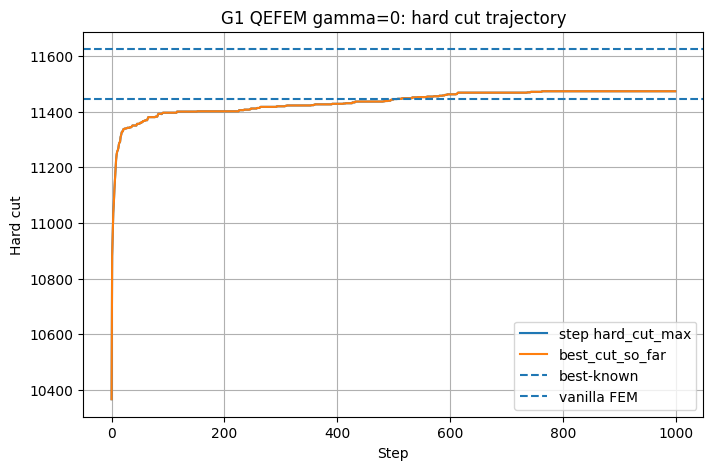

In [76]:
# ----------------------------
# Plot: hard cut trajectory
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(history_zero_df["step"], history_zero_df["hard_cut_max"], label="step hard_cut_max")
plt.plot(history_zero_df["step"], history_zero_df["best_cut_so_far"], label="best_cut_so_far")
plt.axhline(best_known, linestyle="--", label="best-known")
plt.axhline(float(vanilla_row["vanilla_cut"]), linestyle="--", label="vanilla FEM")
plt.xlabel("Step")
plt.ylabel("Hard cut")
plt.title(f"{instance} QEFEM gamma=0: hard cut trajectory")
plt.legend()
plt.grid(True)
plt.show()

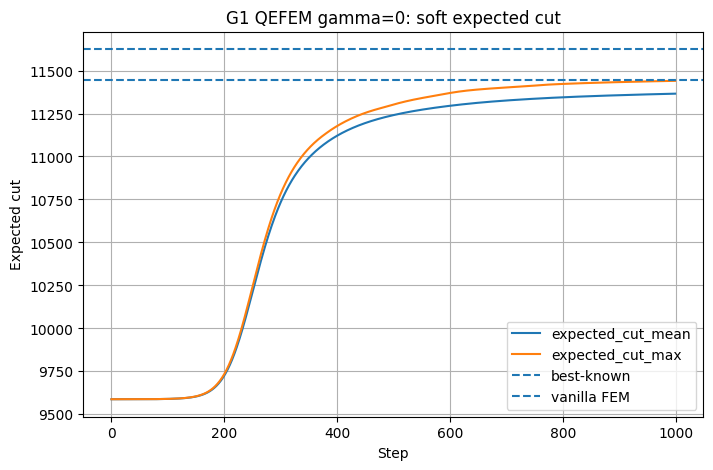

In [77]:
# ----------------------------
# Plot: expected cut trajectory
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(history_zero_df["step"], history_zero_df["expected_cut_mean"], label="expected_cut_mean")
plt.plot(history_zero_df["step"], history_zero_df["expected_cut_max"], label="expected_cut_max")
plt.axhline(best_known, linestyle="--", label="best-known")
plt.axhline(float(vanilla_row["vanilla_cut"]), linestyle="--", label="vanilla FEM")
plt.xlabel("Step")
plt.ylabel("Expected cut")
plt.title(f"{instance} QEFEM gamma=0: soft expected cut")
plt.legend()
plt.grid(True)
plt.show()

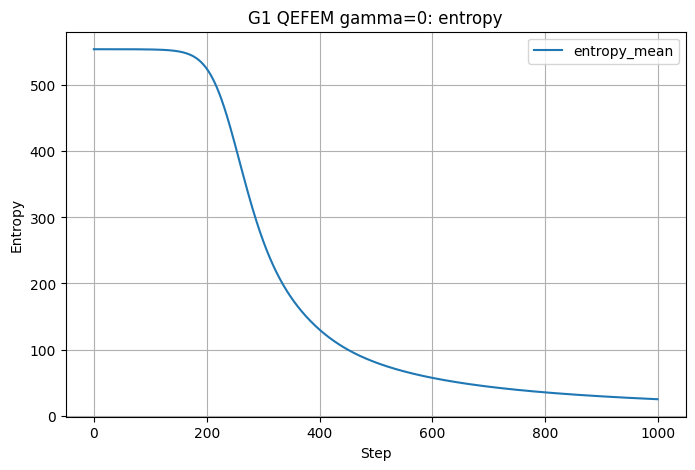

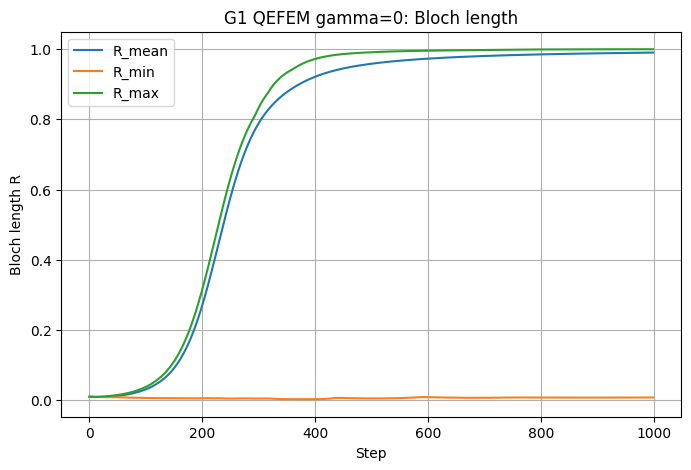

In [78]:
# ----------------------------
# Plot: entropy and Bloch length
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(history_zero_df["step"], history_zero_df["entropy_mean"], label="entropy_mean")
plt.xlabel("Step")
plt.ylabel("Entropy")
plt.title(f"{instance} QEFEM gamma=0: entropy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_zero_df["step"], history_zero_df["R_mean"], label="R_mean")
plt.plot(history_zero_df["step"], history_zero_df["R_min"], label="R_min")
plt.plot(history_zero_df["step"], history_zero_df["R_max"], label="R_max")
plt.xlabel("Step")
plt.ylabel("Bloch length R")
plt.title(f"{instance} QEFEM gamma=0: Bloch length")
plt.legend()
plt.grid(True)
plt.show()

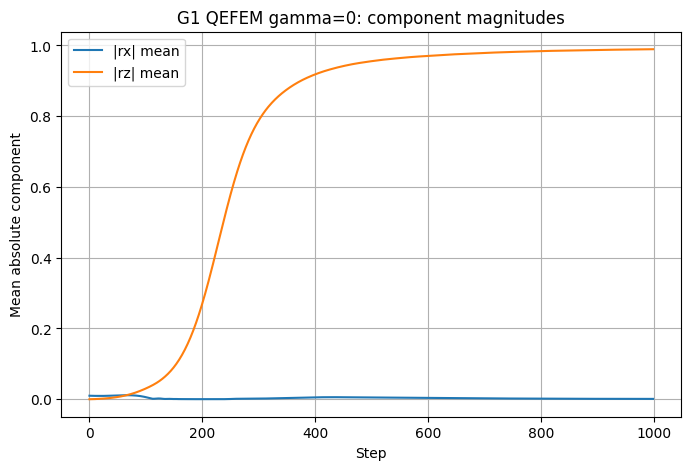

In [79]:
# ----------------------------
# Plot: rx and rz behavior
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(history_zero_df["step"], history_zero_df["rx_abs_mean"], label="|rx| mean")
plt.plot(history_zero_df["step"], history_zero_df["rz_abs_mean"], label="|rz| mean")
plt.xlabel("Step")
plt.ylabel("Mean absolute component")
plt.title(f"{instance} QEFEM gamma=0: component magnitudes")
plt.legend()
plt.grid(True)
plt.show()

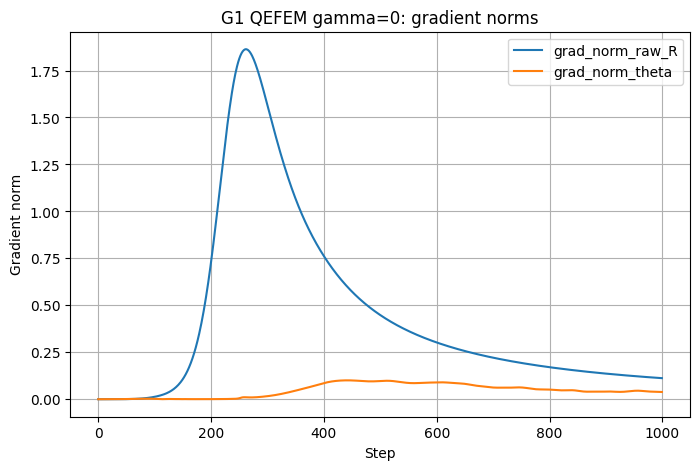

In [80]:
# ----------------------------
# Plot: gradient norms
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(history_zero_df["step"], history_zero_df["grad_norm_raw_R"], label="grad_norm_raw_R")
plt.plot(history_zero_df["step"], history_zero_df["grad_norm_theta"], label="grad_norm_theta")
plt.xlabel("Step")
plt.ylabel("Gradient norm")
plt.title(f"{instance} QEFEM gamma=0: gradient norms")
plt.legend()
plt.grid(True)
plt.show()

In [83]:
# ----------------------------
# Final interpretation printout
# ----------------------------
print("\nInterpretation:")
print(f"Best gamma=0 QEFEM cut: {best_cut_zero:.0f}")
print(f"Vanilla FEM cut: {float(vanilla_row['vanilla_cut']):.0f}")
print(f"Best-known cut: {best_known}")
print(f"Delta cut vs vanilla: {best_cut_zero - float(vanilla_row['vanilla_cut']):.0f}")
print(f"Delta accuracy vs vanilla: {accuracy_zero - float(vanilla_row['vanilla_percent_accuracy']):.4f} percentage points")

if best_cut_zero >= float(vanilla_row["vanilla_cut"]):
    print("\nVerdict: gamma=0 QEFEM is vanilla-esque and slightly better on this run.")
else:
    print("\nVerdict: gamma=0 QEFEM is below vanilla, but check closeness.")


Interpretation:
Best gamma=0 QEFEM cut: 11473
Vanilla FEM cut: 11446
Best-known cut: 11624
Delta cut vs vanilla: 27
Delta accuracy vs vanilla: 0.2323 percentage points

Verdict: gamma=0 QEFEM is vanilla-esque and slightly better on this run.


This is performing exactly as expected due to gamma reward = 0, rx (mixing) never grows!

#### Build single instance QeFEM runner 
for when multiple instances shall be built for different GSets in the for loop

In [87]:
def run_qefem_single_gset(
    instance_name,
    gamma_mode="anneal",
    replicas=REPLICAS,
    n_steps=N_STEPS,
    seed=SEED,
    lr=LR,
    beta_min=BETA_MIN,
    beta_max=BETA_MAX,
    gamma_max=GAMMA_MAX,
    gamma_min=GAMMA_MIN,
    R_init=R_INIT,
    theta_center=THETA_CENTER,
    theta_noise=THETA_NOISE,
    print_every=PRINT_EVERY,
    save_history=True,
    output_dir=OUTPUT_DIR,
    device=device,
    dtype=DTYPE,
):

    # ----------------------------
    # Load graph
    # ----------------------------
    instance_path = DATA_GSET_DIR / instance_name

    W_local, graph_info_local = load_gset_dense(
        instance_path,
        device=device,
        dtype=dtype,
        index_start=1,
    )

    n_local = W_local.shape[0]
    best_value_local = GSET_BEST_KNOWN_ALL[instance_name]

    vanilla_match = vanilla_compare_df.query("instance == @instance_name")

    if len(vanilla_match) != 1:
        raise ValueError(
            f"Expected exactly one vanilla baseline row for {instance_name}, "
            f"found {len(vanilla_match)}."
        )

    vanilla_row_local = vanilla_match.iloc[0]


    # ----------------------------
    # Initialize variables
    # ----------------------------
    raw_R_local, theta_local = initialize_qefem_variables(
        n=n_local,
        replicas=replicas,
        seed=seed,
        R_init=R_init,
        theta_center=theta_center,
        theta_noise=theta_noise,
        device=device,
        dtype=dtype,
    )

    optimizer_local = make_qefem_optimizer(
        raw_R=raw_R_local,
        theta=theta_local,
        lr=lr,
    )


    # ----------------------------
    # Build schedules
    # ----------------------------
    beta_schedule_local = make_beta_schedule(
        beta_min=beta_min,
        beta_max=beta_max,
        n_steps=n_steps,
        kind=BETA_SCHEDULE_KIND,
        device=device,
        dtype=dtype,
    )

    gamma_schedule_local = make_gamma_schedule(
        gamma_mode=gamma_mode,
        gamma_max=gamma_max,
        gamma_min=gamma_min,
        n_steps=n_steps,
        kind=GAMMA_SCHEDULE_KIND,
        device=device,
        dtype=dtype,
    )


    # ----------------------------
    # Run bookkeeping
    # ----------------------------
    history = []

    best_cut = -float("inf")
    best_step = None
    best_replica = None
    best_spins = None

    start_time = time.time()

    print("=" * 80)
    print(f"Running QEFEM single instance: {instance_name}")
    print("=" * 80)
    print("gamma_mode:", gamma_mode)
    print("N:", n_local)
    print("replicas:", replicas)
    print("n_steps:", n_steps)
    print("lr:", lr)
    print("beta:", beta_min, "->", beta_max)

    if gamma_mode == "zero":
        print("gamma: 0.0 fixed")
    elif gamma_mode == "anneal":
        print("gamma:", gamma_max, "->", gamma_min)

    print("best-known:", best_value_local)
    print("vanilla cut:", vanilla_row_local["vanilla_cut"])
    print("-" * 80)


    # ----------------------------
    # Training loop
    # ----------------------------
    for step in range(n_steps):
        beta_t = beta_schedule_local[step]
        gamma_t = gamma_schedule_local[step]

        optimizer_local.zero_grad()

        F, aux = qefem_free_energy_maxcut(
            W=W_local,
            raw_R=raw_R_local,
            theta=theta_local,
            beta=beta_t,
            gamma=gamma_t,
        )

        loss = F.mean()
        loss.backward()

        grad_norm_raw_R = raw_R_local.grad.detach().norm().item()
        grad_norm_theta = theta_local.grad.detach().norm().item()

        optimizer_local.step()

        with torch.no_grad():
            R_now, rx_now, rz_now = bloch_from_raw(raw_R_local, theta_local)

            spins_now = torch.where(
                rz_now >= 0,
                torch.ones_like(rz_now),
                -torch.ones_like(rz_now),
            )

            hard_cuts_now = discrete_cut(W_local, spins_now)

            step_best_cut = float(hard_cuts_now.max().detach().cpu())
            step_best_replica = int(torch.argmax(hard_cuts_now).detach().cpu())

            if step_best_cut > best_cut:
                best_cut = step_best_cut
                best_step = step
                best_replica = step_best_replica
                best_spins = spins_now[step_best_replica].detach().cpu().clone()

            row = {
                "instance": instance_name,
                "step": step,
                "beta": float(beta_t.detach().cpu()),
                "gamma": float(gamma_t.detach().cpu()),

                "loss_mean": float(loss.detach().cpu()),
                "free_energy_mean": float(F.mean().detach().cpu()),

                "expected_cut_mean": float(aux["expected_cut"].mean().detach().cpu()),
                "expected_cut_max": float(aux["expected_cut"].max().detach().cpu()),

                "hard_cut_mean": float(hard_cuts_now.mean().detach().cpu()),
                "hard_cut_max": float(hard_cuts_now.max().detach().cpu()),
                "best_cut_so_far": best_cut,

                "entropy_mean": float(aux["entropy"].mean().detach().cpu()),
                "driver_energy_mean": float(aux["driver_energy"].mean().detach().cpu()),

                "R_mean": float(R_now.mean().detach().cpu()),
                "R_min": float(R_now.min().detach().cpu()),
                "R_max": float(R_now.max().detach().cpu()),

                "rx_mean": float(rx_now.mean().detach().cpu()),
                "rx_abs_mean": float(rx_now.abs().mean().detach().cpu()),

                "rz_mean": float(rz_now.mean().detach().cpu()),
                "rz_abs_mean": float(rz_now.abs().mean().detach().cpu()),

                "grad_norm_raw_R": grad_norm_raw_R,
                "grad_norm_theta": grad_norm_theta,
            }

            history.append(row)

        if (
            step == 0
            or (step + 1) % print_every == 0
            or step == n_steps - 1
        ):
            elapsed = time.time() - start_time

            print(
                f"{instance_name} | "
                f"step {step + 1:4d}/{n_steps} | "
                f"beta={row['beta']:.2f} | "
                f"gamma={row['gamma']:.4f} | "
                f"hard_max={row['hard_cut_max']:.0f} | "
                f"best={row['best_cut_so_far']:.0f} | "
                f"|rx|={row['rx_abs_mean']:.4f} | "
                f"|rz|={row['rz_abs_mean']:.4f} | "
                f"elapsed={elapsed:.2f}s"
            )


    # ----------------------------
    # Finalize
    # ----------------------------
    runtime = time.time() - start_time
    history_df = pd.DataFrame(history)

    gap = best_value_local - best_cut
    percent_accuracy = 100.0 * best_cut / best_value_local

    vanilla_cut = float(vanilla_row_local["vanilla_cut"])
    vanilla_gap = float(vanilla_row_local["vanilla_gap"])
    vanilla_percent_accuracy = float(vanilla_row_local["vanilla_percent_accuracy"])
    vanilla_runtime = float(vanilla_row_local["vanilla_tts_seconds"])

    summary = {
        "instance": instance_name,
        "nodes": n_local,
        "edges": graph_info_local["m_loaded"],

        "mode": f"qefem_{gamma_mode}",
        "gamma_mode": gamma_mode,
        "gamma_max": gamma_max if gamma_mode == "anneal" else 0.0,
        "gamma_min": gamma_min if gamma_mode == "anneal" else 0.0,

        "n_steps": n_steps,
        "replicas": replicas,
        "seed": seed,
        "lr": lr,
        "beta_min": beta_min,
        "beta_max": beta_max,

        "best_cut": best_cut,
        "best_value": best_value_local,
        "gap": gap,
        "percent_accuracy": percent_accuracy,
        "best_step": best_step,
        "best_replica": best_replica,
        "runtime_sec": runtime,

        "vanilla_cut": vanilla_cut,
        "vanilla_gap": vanilla_gap,
        "vanilla_percent_accuracy": vanilla_percent_accuracy,
        "vanilla_runtime_sec": vanilla_runtime,

        "delta_cut_vs_vanilla": best_cut - vanilla_cut,
        "delta_gap_vs_vanilla": vanilla_gap - gap,
        "delta_accuracy_vs_vanilla": percent_accuracy - vanilla_percent_accuracy,
        "runtime_ratio_vs_vanilla": runtime / vanilla_runtime if vanilla_runtime > 0 else np.nan,
    }


    # ----------------------------
    # Save history if requested
    # ----------------------------
    if save_history:
        output_dir = Path(output_dir)
        output_dir.mkdir(exist_ok=True)

        history_path = output_dir / f"{instance_name}_qefem_{gamma_mode}_history.csv"
        history_df.to_csv(history_path, index=False)

        summary_path = output_dir / f"{instance_name}_qefem_{gamma_mode}_summary.csv"
        pd.DataFrame([summary]).to_csv(summary_path, index=False)

        summary["history_path"] = str(history_path)
        summary["summary_path"] = str(summary_path)


    print("\nFinished:", instance_name)
    print("Best cut:", best_cut)
    print("Best-known:", best_value_local)
    print("Gap:", gap)
    print("Accuracy %:", percent_accuracy)
    print("Vanilla cut:", vanilla_cut)
    print("Delta cut vs vanilla:", best_cut - vanilla_cut)
    print("Runtime sec:", runtime)
    print("-" * 80)

    return summary, history_df

### Run Batch 1 ---> {G1,..G10}

In [88]:
assert "run_qefem_single_gset" in globals(), "Run Cell 18 first. Wrapper function is missing."

qefem_g1_g10_summaries = []
qefem_g1_g10_histories = {}

g1_g10_output_path = OUTPUT_DIR / "qefem_anneal_G1_G10_partial_results.csv"

print("=" * 80)
print("Starting QEFEM gamma anneal sweep: G1-G10")
print("=" * 80)
print("Instances:", GSET_FIRST_SWEEP)
print("Partial results will be saved to:")
print(g1_g10_output_path.resolve())
print("=" * 80)

Starting QEFEM gamma anneal sweep: G1-G10
Instances: ['G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'G10']
Partial results will be saved to:
/Users/ronit/Desktop/QeFEM/main/jupyter/qefem_v1_outputs/qefem_anneal_G1_G10_partial_results.csv


In [89]:
for run_idx, instance_name in enumerate(GSET_FIRST_SWEEP, start=1):
    print("\n\n" + "#" * 80)
    print(f"G1-G10 sweep item {run_idx}/{len(GSET_FIRST_SWEEP)}: {instance_name}")
    print("#" * 80)

    summary, history_df = run_qefem_single_gset(
        instance_name=instance_name,
        gamma_mode="anneal",
        replicas=REPLICAS,
        n_steps=N_STEPS,
        seed=SEED,
        lr=LR,
        beta_min=BETA_MIN,
        beta_max=BETA_MAX,
        gamma_max=GAMMA_MAX,
        gamma_min=GAMMA_MIN,
        R_init=R_INIT,
        theta_center=THETA_CENTER,
        theta_noise=THETA_NOISE,
        print_every=PRINT_EVERY,
        save_history=True,
        output_dir=OUTPUT_DIR,
        device=device,
        dtype=DTYPE,
    )

    qefem_g1_g10_summaries.append(summary)
    qefem_g1_g10_histories[instance_name] = history_df

    # Save partial summary after every graph because notebooks enjoy dying at bad times.
    qefem_g1_g10_results_df = pd.DataFrame(qefem_g1_g10_summaries)
    qefem_g1_g10_results_df.to_csv(g1_g10_output_path, index=False)

    print("\nCurrent partial G1-G10 results:")
    display(qefem_g1_g10_results_df[
        [
            "instance",
            "best_cut",
            "best_value",
            "gap",
            "percent_accuracy",
            "vanilla_cut",
            "delta_cut_vs_vanilla",
            "delta_accuracy_vs_vanilla",
            "runtime_sec",
        ]
    ])



################################################################################
G1-G10 sweep item 1/10: G1
################################################################################
Running QEFEM single instance: G1
gamma_mode: anneal
N: 800
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 11624
vanilla cut: 11446.0
--------------------------------------------------------------------------------
G1 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=9647 | best=9647 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.02s
G1 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=9788 | best=9904 | |rx|=0.0312 | |rz|=0.0000 | elapsed=1.66s
G1 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=7848 | best=9904 | |rx|=0.1512 | |rz|=0.0001 | elapsed=3.69s
G1 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=11600 | best=11600 | |rx|=0.1821 | |rz|=0.6212 | elapsed=5.68s
G1 | step  400/1000 | beta=4993.69 | gamma=0.6006 | hard_max=11610

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
0,G1,11611.0,11624,13.0,99.888162,11446.0,165.0,1.419477,20.077096




################################################################################
G1-G10 sweep item 2/10: G2
################################################################################
Running QEFEM single instance: G2
gamma_mode: anneal
N: 800
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 11620
vanilla cut: 11435.0
--------------------------------------------------------------------------------
G2 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=9723 | best=9723 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.01s
G2 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=9803 | best=9912 | |rx|=0.0312 | |rz|=0.0000 | elapsed=1.47s
G2 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=3731 | best=9912 | |rx|=0.1512 | |rz|=0.0001 | elapsed=3.55s
G2 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=11594 | best=11594 | |rx|=0.1816 | |rz|=0.6219 | elapsed=5.67s
G2 | step  400/1000 | beta=4993.69 | gamma=0.6006 | hard_max=11610

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
0,G1,11611.0,11624,13.0,99.888162,11446.0,165.0,1.419477,20.077096
1,G2,11610.0,11620,10.0,99.913941,11435.0,175.0,1.506024,20.023929




################################################################################
G1-G10 sweep item 3/10: G3
################################################################################
Running QEFEM single instance: G3
gamma_mode: anneal
N: 800
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 11622
vanilla cut: 11443.0
--------------------------------------------------------------------------------
G3 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=9716 | best=9716 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.01s
G3 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=9784 | best=9901 | |rx|=0.0312 | |rz|=0.0000 | elapsed=1.53s
G3 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=7408 | best=9901 | |rx|=0.1512 | |rz|=0.0001 | elapsed=3.57s
G3 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=11601 | best=11601 | |rx|=0.1812 | |rz|=0.6223 | elapsed=5.46s
G3 | step  400/1000 | beta=4993.69 | gamma=0.6006 | hard_max=11608

...

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
0,G1,11611.0,11624,13.0,99.888162,11446.0,165.0,1.419477,20.077096
1,G2,11610.0,11620,10.0,99.913941,11435.0,175.0,1.506024,20.023929
2,G3,11610.0,11622,12.0,99.896748,11443.0,167.0,1.436930,19.558286
3,G4,11637.0,11646,9.0,99.922720,11503.0,134.0,1.150610,19.926327
4,G5,11622.0,11631,9.0,99.922621,11450.0,172.0,1.478807,20.084831
5,G6,2173.0,2178,5.0,99.770432,1978.0,195.0,8.953168,19.604576
6,G7,1992.0,2006,14.0,99.302094,1822.0,170.0,8.474576,19.974821
7,G8,1991.0,2005,14.0,99.301746,1856.0,135.0,6.733167,19.874761




################################################################################
G1-G10 sweep item 9/10: G9
################################################################################
Running QEFEM single instance: G9
gamma_mode: anneal
N: 800
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 2054
vanilla cut: 1840.0
--------------------------------------------------------------------------------
G9 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=80 | best=80 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.01s
G9 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=177 | best=272 | |rx|=0.0312 | |rz|=0.0000 | elapsed=1.48s
G9 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=1655 | best=1655 | |rx|=0.1512 | |rz|=0.0003 | elapsed=3.48s
G9 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=2040 | best=2040 | |rx|=0.1762 | |rz|=0.6353 | elapsed=5.56s
G9 | step  400/1000 | beta=4993.69 | gamma=0.6006 | hard_max=2041 | best=204

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
0,G1,11611.0,11624,13.0,99.888162,11446.0,165.0,1.419477,20.077096
1,G2,11610.0,11620,10.0,99.913941,11435.0,175.0,1.506024,20.023929
2,G3,11610.0,11622,12.0,99.896748,11443.0,167.0,1.436930,19.558286
3,G4,11637.0,11646,9.0,99.922720,11503.0,134.0,1.150610,19.926327
4,G5,11622.0,11631,9.0,99.922621,11450.0,172.0,1.478807,20.084831
5,G6,2173.0,2178,5.0,99.770432,1978.0,195.0,8.953168,19.604576
6,G7,1992.0,2006,14.0,99.302094,1822.0,170.0,8.474576,19.974821
7,G8,1991.0,2005,14.0,99.301746,1856.0,135.0,6.733167,19.874761
8,G9,2041.0,2054,13.0,99.367089,1840.0,201.0,9.785784,19.579863




################################################################################
G1-G10 sweep item 10/10: G10
################################################################################
Running QEFEM single instance: G10
gamma_mode: anneal
N: 800
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 2000
vanilla cut: 1819.0
--------------------------------------------------------------------------------
G10 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=27 | best=27 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.01s
G10 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=111 | best=226 | |rx|=0.0312 | |rz|=0.0000 | elapsed=1.61s
G10 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=1428 | best=1428 | |rx|=0.1512 | |rz|=0.0003 | elapsed=3.60s
G10 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=1983 | best=1983 | |rx|=0.1769 | |rz|=0.6343 | elapsed=5.65s
G10 | step  400/1000 | beta=4993.69 | gamma=0.6006 | hard_max=1991 | 

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
0,G1,11611.0,11624,13.0,99.888162,11446.0,165.0,1.419477,20.077096
1,G2,11610.0,11620,10.0,99.913941,11435.0,175.0,1.506024,20.023929
2,G3,11610.0,11622,12.0,99.896748,11443.0,167.0,1.436930,19.558286
3,G4,11637.0,11646,9.0,99.922720,11503.0,134.0,1.150610,19.926327
4,G5,11622.0,11631,9.0,99.922621,11450.0,172.0,1.478807,20.084831
5,G6,2173.0,2178,5.0,99.770432,1978.0,195.0,8.953168,19.604576
6,G7,1992.0,2006,14.0,99.302094,1822.0,170.0,8.474576,19.974821
7,G8,1991.0,2005,14.0,99.301746,1856.0,135.0,6.733167,19.874761
8,G9,2041.0,2054,13.0,99.367089,1840.0,201.0,9.785784,19.579863
9,G10,1992.0,2000,8.0,99.600000,1819.0,173.0,8.650000,19.915456


In [90]:

# ----------------------------
# Finalize G1-G10 result file
# ----------------------------
qefem_g1_g10_results_df = pd.DataFrame(qefem_g1_g10_summaries)

final_g1_g10_path = OUTPUT_DIR / "qefem_anneal_G1_G10_final_results.csv"
qefem_g1_g10_results_df.to_csv(final_g1_g10_path, index=False)

print("\n" + "=" * 80)
print("G1-G10 QEFEM gamma anneal sweep complete")
print("=" * 80)

display(qefem_g1_g10_results_df[
    [
        "instance",
        "best_cut",
        "best_value",
        "gap",
        "percent_accuracy",
        "vanilla_cut",
        "delta_cut_vs_vanilla",
        "delta_accuracy_vs_vanilla",
        "runtime_sec",
    ]
])

print("\nSaved final G1-G10 results to:")
print(final_g1_g10_path.resolve())


G1-G10 QEFEM gamma anneal sweep complete


,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
0,G1,11611.0,11624,13.0,99.888162,11446.0,165.0,1.419477,20.077096
1,G2,11610.0,11620,10.0,99.913941,11435.0,175.0,1.506024,20.023929
2,G3,11610.0,11622,12.0,99.896748,11443.0,167.0,1.436930,19.558286
3,G4,11637.0,11646,9.0,99.922720,11503.0,134.0,1.150610,19.926327
4,G5,11622.0,11631,9.0,99.922621,11450.0,172.0,1.478807,20.084831
5,G6,2173.0,2178,5.0,99.770432,1978.0,195.0,8.953168,19.604576
6,G7,1992.0,2006,14.0,99.302094,1822.0,170.0,8.474576,19.974821
7,G8,1991.0,2005,14.0,99.301746,1856.0,135.0,6.733167,19.874761
8,G9,2041.0,2054,13.0,99.367089,1840.0,201.0,9.785784,19.579863
9,G10,1992.0,2000,8.0,99.600000,1819.0,173.0,8.650000,19.915456



Saved final G1-G10 results to:
/Users/ronit/Desktop/QeFEM/main/jupyter/qefem_v1_outputs/qefem_anneal_G1_G10_final_results.csv


In [91]:
# ----------------------------
# Aggregate summary
# ----------------------------
num_wins = int((qefem_g1_g10_results_df["delta_cut_vs_vanilla"] > 0).sum())
num_ties = int((qefem_g1_g10_results_df["delta_cut_vs_vanilla"] == 0).sum())
num_losses = int((qefem_g1_g10_results_df["delta_cut_vs_vanilla"] < 0).sum())

mean_delta_cut = float(qefem_g1_g10_results_df["delta_cut_vs_vanilla"].mean())
mean_delta_accuracy = float(qefem_g1_g10_results_df["delta_accuracy_vs_vanilla"].mean())
mean_accuracy = float(qefem_g1_g10_results_df["percent_accuracy"].mean())
mean_runtime = float(qefem_g1_g10_results_df["runtime_sec"].mean())

print("\nAggregate G1-G10 summary:")
print("Wins vs vanilla:", num_wins)
print("Ties vs vanilla:", num_ties)
print("Losses vs vanilla:", num_losses)
print("Mean delta cut vs vanilla:", mean_delta_cut)
print("Mean delta accuracy vs vanilla:", mean_delta_accuracy)
print("Mean QEFEM accuracy %:", mean_accuracy)
print("Mean runtime sec:", mean_runtime)


Aggregate G1-G10 summary:
Wins vs vanilla: 10
Ties vs vanilla: 0
Losses vs vanilla: 0
Mean delta cut vs vanilla: 168.7
Mean delta accuracy vs vanilla: 4.958854252385012
Mean QEFEM accuracy %: 99.6885551831717
Mean runtime sec: 19.861994600296022


### Inference & Diagnostics

In [92]:
# ============================================================
# Cell 20: Analyze G1-G10 QEFEM vs vanilla results
# ============================================================

# This cell does NOT rerun anything.
# It analyzes the completed G1-G10 QEFEM anneal sweep from Cell 19.

assert "qefem_g1_g10_results_df" in globals(), (
    "Run Cell 19 first. qefem_g1_g10_results_df does not exist."
)

assert len(qefem_g1_g10_results_df) > 0, (
    "qefem_g1_g10_results_df is empty. The dataframe goblin ate your sweep."
)


# ----------------------------
# Make clean comparison dataframe
# ----------------------------
g1_g10_analysis_df = qefem_g1_g10_results_df.copy()

# Helpful columns
g1_g10_analysis_df["cut_improvement_percent_vs_vanilla"] = (
    100.0
    * g1_g10_analysis_df["delta_cut_vs_vanilla"]
    / g1_g10_analysis_df["vanilla_cut"]
)

g1_g10_analysis_df["gap_reduction_percent_vs_vanilla"] = (
    100.0
    * g1_g10_analysis_df["delta_gap_vs_vanilla"]
    / g1_g10_analysis_df["vanilla_gap"]
)

g1_g10_analysis_df["qefem_minus_best_known"] = (
    g1_g10_analysis_df["best_cut"] - g1_g10_analysis_df["best_value"]
)

g1_g10_analysis_df["hit_best_known"] = (
    g1_g10_analysis_df["best_cut"] >= g1_g10_analysis_df["best_value"]
)

g1_g10_analysis_df["winner"] = np.where(
    g1_g10_analysis_df["delta_cut_vs_vanilla"] > 0,
    "QEFEM",
    np.where(
        g1_g10_analysis_df["delta_cut_vs_vanilla"] < 0,
        "Vanilla",
        "Tie",
    )
)

In [93]:
# ----------------------------
# Display main table
# ----------------------------
main_cols = [
    "instance",
    "best_cut",
    "vanilla_cut",
    "best_value",
    "gap",
    "vanilla_gap",
    "percent_accuracy",
    "vanilla_percent_accuracy",
    "delta_cut_vs_vanilla",
    "cut_improvement_percent_vs_vanilla",
    "delta_accuracy_vs_vanilla",
    "gap_reduction_percent_vs_vanilla",
    "runtime_sec",
    "vanilla_runtime_sec",
    "runtime_ratio_vs_vanilla",
    "winner",
]

print("G1-G10 QEFEM vs vanilla comparison:")
display(g1_g10_analysis_df[main_cols])


# ----------------------------
# Save analysis table
# ----------------------------
g1_g10_analysis_path = OUTPUT_DIR / "qefem_anneal_G1_G10_analysis_vs_vanilla.csv"
g1_g10_analysis_df.to_csv(g1_g10_analysis_path, index=False)

print("\nSaved G1-G10 analysis to:")
print(g1_g10_analysis_path.resolve())

G1-G10 QEFEM vs vanilla comparison:


,instance,best_cut,vanilla_cut,best_value,gap,vanilla_gap,percent_accuracy,vanilla_percent_accuracy,delta_cut_vs_vanilla,cut_improvement_percent_vs_vanilla,delta_accuracy_vs_vanilla,gap_reduction_percent_vs_vanilla,runtime_sec,vanilla_runtime_sec,runtime_ratio_vs_vanilla,winner
0,G1,11611.0,11446.0,11624,13.0,178.0,99.888162,98.468685,165.0,1.441552,1.419477,92.696629,20.077096,4.368305,4.596084,QEFEM
1,G2,11610.0,11435.0,11620,10.0,185.0,99.913941,98.407917,175.0,1.530389,1.506024,94.594595,20.023929,4.299664,4.657091,QEFEM
2,G3,11610.0,11443.0,11622,12.0,179.0,99.896748,98.459818,167.0,1.459407,1.436930,93.296089,19.558286,4.356321,4.489634,QEFEM
3,G4,11637.0,11503.0,11646,9.0,143.0,99.922720,98.772111,134.0,1.164914,1.150610,93.706294,19.926327,4.275009,4.661119,QEFEM
4,G5,11622.0,11450.0,11631,9.0,181.0,99.922621,98.443814,172.0,1.502183,1.478807,95.027624,20.084831,4.161925,4.825851,QEFEM
5,G6,2173.0,1978.0,2178,5.0,200.0,99.770432,90.817264,195.0,9.858443,8.953168,97.500000,19.604576,4.394011,4.461659,QEFEM
6,G7,1992.0,1822.0,2006,14.0,184.0,99.302094,90.827517,170.0,9.330406,8.474576,92.391304,19.974821,4.333263,4.609649,QEFEM
7,G8,1991.0,1856.0,2005,14.0,149.0,99.301746,92.568579,135.0,7.273707,6.733167,90.604027,19.874761,4.411136,4.505588,QEFEM
8,G9,2041.0,1840.0,2054,13.0,214.0,99.367089,89.581305,201.0,10.923913,9.785784,93.925234,19.579863,4.523476,4.328499,QEFEM
9,G10,1992.0,1819.0,2000,8.0,181.0,99.600000,90.950000,173.0,9.510720,8.650000,95.580110,19.915456,4.260001,4.674989,QEFEM



Saved G1-G10 analysis to:
/Users/ronit/Desktop/QeFEM/main/jupyter/qefem_v1_outputs/qefem_anneal_G1_G10_analysis_vs_vanilla.csv


In [94]:
# ----------------------------
# Aggregate statistics
# ----------------------------
num_instances = len(g1_g10_analysis_df)

wins = int((g1_g10_analysis_df["winner"] == "QEFEM").sum())
ties = int((g1_g10_analysis_df["winner"] == "Tie").sum())
losses = int((g1_g10_analysis_df["winner"] == "Vanilla").sum())

mean_qefem_cut = float(g1_g10_analysis_df["best_cut"].mean())
mean_vanilla_cut = float(g1_g10_analysis_df["vanilla_cut"].mean())
mean_best_value = float(g1_g10_analysis_df["best_value"].mean())

mean_delta_cut = float(g1_g10_analysis_df["delta_cut_vs_vanilla"].mean())
median_delta_cut = float(g1_g10_analysis_df["delta_cut_vs_vanilla"].median())
min_delta_cut = float(g1_g10_analysis_df["delta_cut_vs_vanilla"].min())
max_delta_cut = float(g1_g10_analysis_df["delta_cut_vs_vanilla"].max())

mean_cut_improvement_percent = float(
    g1_g10_analysis_df["cut_improvement_percent_vs_vanilla"].mean()
)

mean_qefem_accuracy = float(g1_g10_analysis_df["percent_accuracy"].mean())
mean_vanilla_accuracy = float(g1_g10_analysis_df["vanilla_percent_accuracy"].mean())
mean_delta_accuracy = float(g1_g10_analysis_df["delta_accuracy_vs_vanilla"].mean())

mean_gap = float(g1_g10_analysis_df["gap"].mean())
mean_vanilla_gap = float(g1_g10_analysis_df["vanilla_gap"].mean())
mean_gap_reduction = float(g1_g10_analysis_df["delta_gap_vs_vanilla"].mean())
mean_gap_reduction_percent = float(
    g1_g10_analysis_df["gap_reduction_percent_vs_vanilla"].mean()
)

best_known_hits = int(g1_g10_analysis_df["hit_best_known"].sum())

mean_runtime = float(g1_g10_analysis_df["runtime_sec"].mean())
mean_vanilla_runtime = float(g1_g10_analysis_df["vanilla_runtime_sec"].mean())
mean_runtime_ratio = float(g1_g10_analysis_df["runtime_ratio_vs_vanilla"].mean())


g1_g10_aggregate_summary = {
    "num_instances": num_instances,

    "wins_vs_vanilla": wins,
    "ties_vs_vanilla": ties,
    "losses_vs_vanilla": losses,

    "mean_qefem_cut": mean_qefem_cut,
    "mean_vanilla_cut": mean_vanilla_cut,
    "mean_best_value": mean_best_value,

    "mean_delta_cut_vs_vanilla": mean_delta_cut,
    "median_delta_cut_vs_vanilla": median_delta_cut,
    "min_delta_cut_vs_vanilla": min_delta_cut,
    "max_delta_cut_vs_vanilla": max_delta_cut,
    "mean_cut_improvement_percent_vs_vanilla": mean_cut_improvement_percent,

    "mean_qefem_accuracy_percent": mean_qefem_accuracy,
    "mean_vanilla_accuracy_percent": mean_vanilla_accuracy,
    "mean_delta_accuracy_percentage_points": mean_delta_accuracy,

    "mean_qefem_gap": mean_gap,
    "mean_vanilla_gap": mean_vanilla_gap,
    "mean_gap_reduction": mean_gap_reduction,
    "mean_gap_reduction_percent": mean_gap_reduction_percent,

    "best_known_hits": best_known_hits,

    "mean_qefem_runtime_sec": mean_runtime,
    "mean_vanilla_runtime_sec": mean_vanilla_runtime,
    "mean_runtime_ratio_vs_vanilla": mean_runtime_ratio,
}

g1_g10_aggregate_summary_df = pd.DataFrame([g1_g10_aggregate_summary])

aggregate_path = OUTPUT_DIR / "qefem_anneal_G1_G10_aggregate_summary.csv"
g1_g10_aggregate_summary_df.to_csv(aggregate_path, index=False)

print("\nAggregate G1-G10 summary:")
display(g1_g10_aggregate_summary_df)

print("\nSaved aggregate summary to:")
print(aggregate_path.resolve())


Aggregate G1-G10 summary:


,num_instances,wins_vs_vanilla,ties_vs_vanilla,losses_vs_vanilla,mean_qefem_cut,mean_vanilla_cut,mean_best_value,mean_delta_cut_vs_vanilla,median_delta_cut_vs_vanilla,min_delta_cut_vs_vanilla,...,mean_vanilla_accuracy_percent,mean_delta_accuracy_percentage_points,mean_qefem_gap,mean_vanilla_gap,mean_gap_reduction,mean_gap_reduction_percent,best_known_hits,mean_qefem_runtime_sec,mean_vanilla_runtime_sec,mean_runtime_ratio_vs_vanilla
0,10,10,0,0,6827.9,6659.2,6838.6,168.7,171.0,134.0,...,94.729701,4.958854,10.7,179.4,168.7,93.932191,0,19.861995,4.338311,4.581016



Saved aggregate summary to:
/Users/ronit/Desktop/QeFEM/main/jupyter/qefem_v1_outputs/qefem_anneal_G1_G10_aggregate_summary.csv


In [95]:
# ----------------------------
# Pretty print key results
# ----------------------------
print("\n" + "=" * 80)
print("G1-G10 HEAD-TO-HEAD SUMMARY")
print("=" * 80)
print(f"Wins / ties / losses vs vanilla: {wins} / {ties} / {losses}")
print(f"Mean QEFEM accuracy: {mean_qefem_accuracy:.4f}%")
print(f"Mean vanilla accuracy: {mean_vanilla_accuracy:.4f}%")
print(f"Mean accuracy gain: {mean_delta_accuracy:.4f} percentage points")
print(f"Mean cut gain: {mean_delta_cut:.2f}")
print(f"Mean cut-value improvement vs vanilla: {mean_cut_improvement_percent:.4f}%")
print(f"Mean vanilla gap: {mean_vanilla_gap:.2f}")
print(f"Mean QEFEM gap: {mean_gap:.2f}")
print(f"Mean gap reduction: {mean_gap_reduction:.2f}")
print(f"Mean gap reduction percent: {mean_gap_reduction_percent:.2f}%")
print(f"Best-known hits: {best_known_hits}/{num_instances}")
print(f"Mean QEFEM runtime: {mean_runtime:.2f}s")
print(f"Mean vanilla runtime: {mean_vanilla_runtime:.2f}s")
print(f"Runtime ratio QEFEM/vanilla: {mean_runtime_ratio:.2f}x")
print("=" * 80)


G1-G10 HEAD-TO-HEAD SUMMARY
Wins / ties / losses vs vanilla: 10 / 0 / 0
Mean QEFEM accuracy: 99.6886%
Mean vanilla accuracy: 94.7297%
Mean accuracy gain: 4.9589 percentage points
Mean cut gain: 168.70
Mean cut-value improvement vs vanilla: 5.3996%
Mean vanilla gap: 179.40
Mean QEFEM gap: 10.70
Mean gap reduction: 168.70
Mean gap reduction percent: 93.93%
Best-known hits: 0/10
Mean QEFEM runtime: 19.86s
Mean vanilla runtime: 4.34s
Runtime ratio QEFEM/vanilla: 4.58x


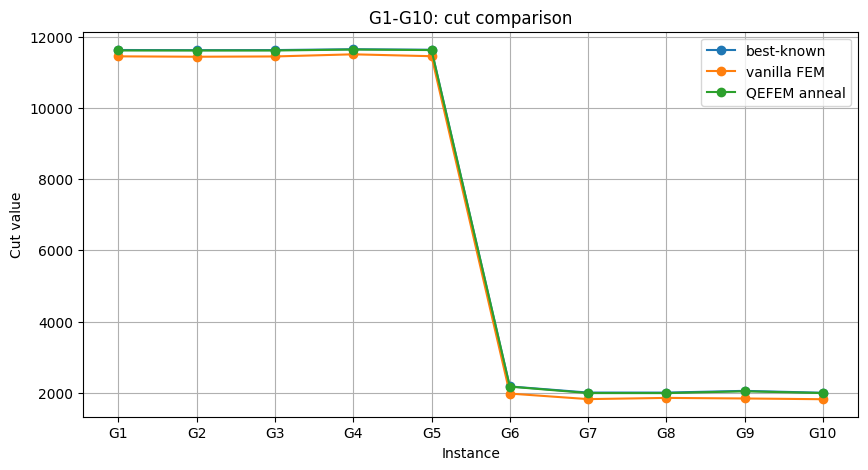

In [96]:
# ----------------------------
# Plot: cut comparison
# ----------------------------
x = np.arange(len(g1_g10_analysis_df))
labels = g1_g10_analysis_df["instance"].tolist()

plt.figure(figsize=(10, 5))
plt.plot(x, g1_g10_analysis_df["best_value"], marker="o", label="best-known")
plt.plot(x, g1_g10_analysis_df["vanilla_cut"], marker="o", label="vanilla FEM")
plt.plot(x, g1_g10_analysis_df["best_cut"], marker="o", label="QEFEM anneal")
plt.xticks(x, labels)
plt.xlabel("Instance")
plt.ylabel("Cut value")
plt.title("G1-G10: cut comparison")
plt.legend()
plt.grid(True)
plt.show()

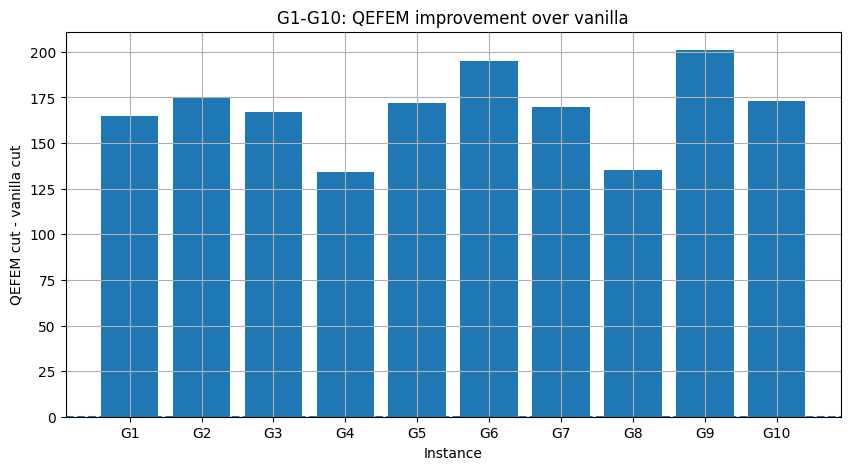

In [97]:
# ----------------------------
# Plot: delta cut vs vanilla
# ----------------------------
plt.figure(figsize=(10, 5))
plt.bar(g1_g10_analysis_df["instance"], g1_g10_analysis_df["delta_cut_vs_vanilla"])
plt.axhline(0, linestyle="--")
plt.xlabel("Instance")
plt.ylabel("QEFEM cut - vanilla cut")
plt.title("G1-G10: QEFEM improvement over vanilla")
plt.grid(True)
plt.show()

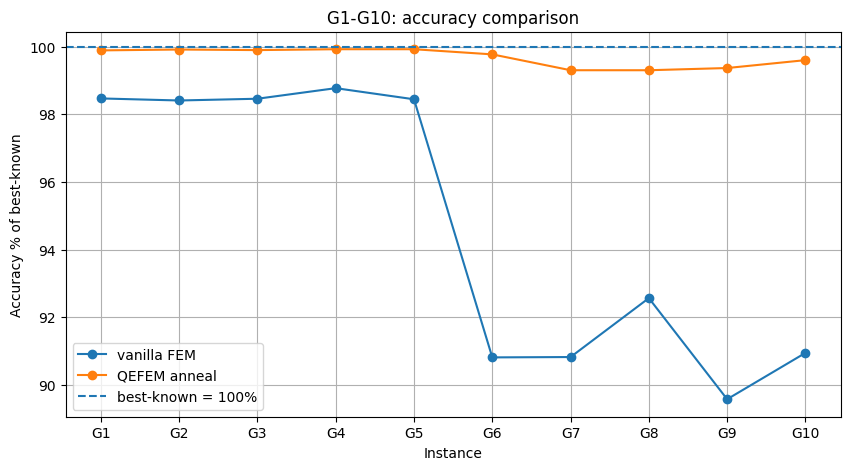

In [98]:
# ----------------------------
# Plot: accuracy comparison
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(x, g1_g10_analysis_df["vanilla_percent_accuracy"], marker="o", label="vanilla FEM")
plt.plot(x, g1_g10_analysis_df["percent_accuracy"], marker="o", label="QEFEM anneal")
plt.axhline(100.0, linestyle="--", label="best-known = 100%")
plt.xticks(x, labels)
plt.xlabel("Instance")
plt.ylabel("Accuracy % of best-known")
plt.title("G1-G10: accuracy comparison")
plt.legend()
plt.grid(True)
plt.show()

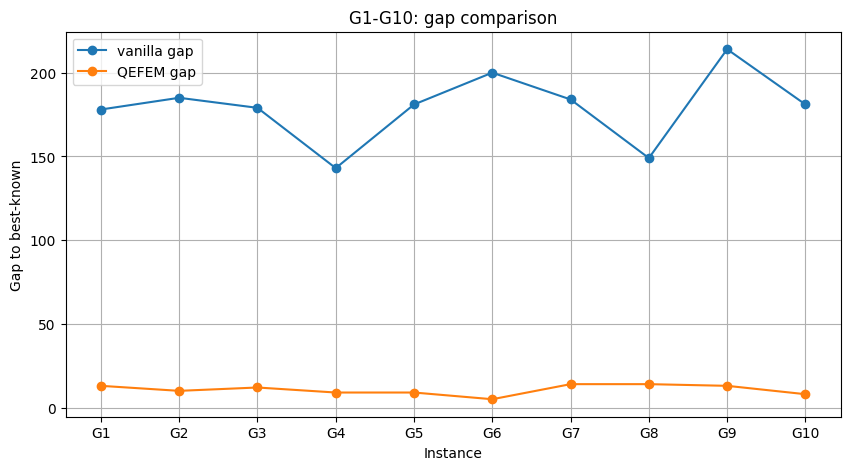

In [99]:
# ----------------------------
# Plot: gap comparison
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(x, g1_g10_analysis_df["vanilla_gap"], marker="o", label="vanilla gap")
plt.plot(x, g1_g10_analysis_df["gap"], marker="o", label="QEFEM gap")
plt.xticks(x, labels)
plt.xlabel("Instance")
plt.ylabel("Gap to best-known")
plt.title("G1-G10: gap comparison")
plt.legend()
plt.grid(True)
plt.show()


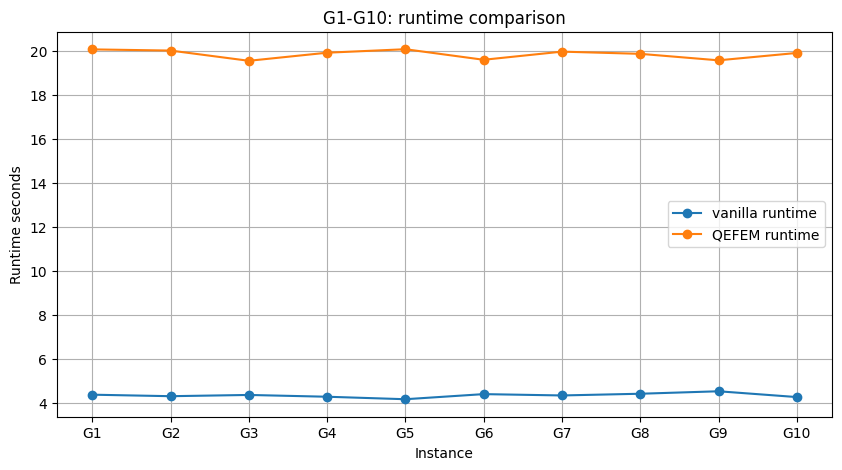

In [100]:
# ----------------------------
# Plot: runtime comparison
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(x, g1_g10_analysis_df["vanilla_runtime_sec"], marker="o", label="vanilla runtime")
plt.plot(x, g1_g10_analysis_df["runtime_sec"], marker="o", label="QEFEM runtime")
plt.xticks(x, labels)
plt.xlabel("Instance")
plt.ylabel("Runtime seconds")
plt.title("G1-G10: runtime comparison")
plt.legend()
plt.grid(True)
plt.show()

In [102]:
# ----------------------------
# Final verdict
# ----------------------------
print("\nVerdict:")

if wins == num_instances:
    print(
        f"QEFEM anneal beats vanilla on all {num_instances}/{num_instances} G1-G10 instances. "
        "This is a very strong first mini-benchmark."
    )
elif wins > losses:
    print(
        "QEFEM anneal wins more often than it loses on G1-G10. Encouraging, but inspect instance-level behavior."
    )
else:
    print(
        "QEFEM anneal does not clearly beat vanilla on G1-G10. Inspect schedules, initialization, and diagnostics."
    )


Verdict:
QEFEM anneal beats vanilla on all 10/10 G1-G10 instances. This is a very strong first mini-benchmark.


### Run PROBLEM BATCH : 
Batch 6 - {35,...,42}

In [103]:
assert "run_qefem_single_gset" in globals(), "Run Cell 18 first. Wrapper function is missing."

qefem_g35_g42_summaries = []
qefem_g35_g42_histories = {}

g35_g42_output_path = OUTPUT_DIR / "qefem_anneal_G35_G42_partial_results.csv"

print("=" * 80)
print("Starting QEFEM gamma anneal sweep: G35-G42 problem batch")
print("=" * 80)
print("Instances:", GSET_PROBLEM_BATCH)
print("Partial results will be saved to:")
print(g35_g42_output_path.resolve())
print("=" * 80)

Starting QEFEM gamma anneal sweep: G35-G42 problem batch
Instances: ['G35', 'G36', 'G37', 'G38', 'G39', 'G40', 'G41', 'G42']
Partial results will be saved to:
/Users/ronit/Desktop/QeFEM/main/jupyter/qefem_v1_outputs/qefem_anneal_G35_G42_partial_results.csv


In [104]:
for run_idx, instance_name in enumerate(GSET_PROBLEM_BATCH, start=1):
    print("\n\n" + "#" * 80)
    print(f"G35-G42 sweep item {run_idx}/{len(GSET_PROBLEM_BATCH)}: {instance_name}")
    print("#" * 80)

    summary, history_df = run_qefem_single_gset(
        instance_name=instance_name,
        gamma_mode="anneal",
        replicas=REPLICAS,
        n_steps=N_STEPS,
        seed=SEED,
        lr=LR,
        beta_min=BETA_MIN,
        beta_max=BETA_MAX,
        gamma_max=GAMMA_MAX,
        gamma_min=GAMMA_MIN,
        R_init=R_INIT,
        theta_center=THETA_CENTER,
        theta_noise=THETA_NOISE,
        print_every=PRINT_EVERY,
        save_history=True,
        output_dir=OUTPUT_DIR,
        device=device,
        dtype=DTYPE,
    )

    qefem_g35_g42_summaries.append(summary)
    qefem_g35_g42_histories[instance_name] = history_df

    # Save partial summary after every graph because notebooks die with theatrical timing.
    qefem_g35_g42_results_df = pd.DataFrame(qefem_g35_g42_summaries)
    qefem_g35_g42_results_df.to_csv(g35_g42_output_path, index=False)

    print("\nCurrent partial G35-G42 results:")
    display(qefem_g35_g42_results_df[
        [
            "instance",
            "best_cut",
            "best_value",
            "gap",
            "percent_accuracy",
            "vanilla_cut",
            "delta_cut_vs_vanilla",
            "delta_accuracy_vs_vanilla",
            "runtime_sec",
        ]
    ])



################################################################################
G35-G42 sweep item 1/8: G35
################################################################################
Running QEFEM single instance: G35
gamma_mode: anneal
N: 2000
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 7687
vanilla cut: 7523.0
--------------------------------------------------------------------------------
G35 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=6023 | best=6023 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.60s
G35 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=5938 | best=6182 | |rx|=0.0312 | |rz|=0.0000 | elapsed=2.70s
G35 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=4309 | best=6182 | |rx|=0.1512 | |rz|=0.0001 | elapsed=5.62s
G35 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=7537 | best=7539 | |rx|=0.4199 | |rz|=0.3550 | elapsed=8.56s
G35 | step  400/1000 | beta=4993.69 | gamma=0.6006 | hard_max=7

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
0,G35,7612.0,7687,75.0,99.024327,7523.0,89.0,1.157799,29.000239




################################################################################
G35-G42 sweep item 2/8: G36
################################################################################
Running QEFEM single instance: G36
gamma_mode: anneal
N: 2000
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 7680
vanilla cut: 7515.0
--------------------------------------------------------------------------------
G36 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=5961 | best=5961 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.02s
G36 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=5949 | best=6184 | |rx|=0.0312 | |rz|=0.0000 | elapsed=2.35s
G36 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=4592 | best=6184 | |rx|=0.1512 | |rz|=0.0001 | elapsed=5.34s
G36 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=7517 | best=7517 | |rx|=0.4207 | |rz|=0.3553 | elapsed=8.30s
G36 | step  400/1000 | beta=4993.69 | gamma=0.6006 | hard_max=7

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
0,G35,7612.0,7687,75.0,99.024327,7523.0,89.0,1.157799,29.000239
1,G36,7599.0,7680,81.0,98.945312,7515.0,84.0,1.093750,28.615590




################################################################################
G35-G42 sweep item 3/8: G37
################################################################################
Running QEFEM single instance: G37
gamma_mode: anneal
N: 2000
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 7691
vanilla cut: 7520.0
--------------------------------------------------------------------------------
G37 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=5987 | best=5987 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.02s
G37 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=5977 | best=6202 | |rx|=0.0312 | |rz|=0.0000 | elapsed=2.23s
G37 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=4476 | best=6202 | |rx|=0.1512 | |rz|=0.0001 | elapsed=5.19s
G37 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=7548 | best=7548 | |rx|=0.4196 | |rz|=0.3575 | elapsed=8.14s
G37 | step  400/1000 | beta=4993.69 | gamma=0.6006 | hard_max=7

...

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
0,G35,7612.0,7687,75.0,99.024327,7523.0,89.0,1.157799,29.000239
1,G36,7599.0,7680,81.0,98.945312,7515.0,84.0,1.093750,28.615590
2,G37,7619.0,7691,72.0,99.063841,7520.0,99.0,1.287219,28.553064
3,G38,7616.0,7688,72.0,99.063476,7514.0,102.0,1.326743,28.457916
4,G39,2336.0,2408,72.0,97.009967,2188.0,148.0,6.146179,28.422576
5,G40,2296.0,2400,104.0,95.666667,2183.0,113.0,4.708333,28.318182




################################################################################
G35-G42 sweep item 7/8: G41
################################################################################
Running QEFEM single instance: G41
gamma_mode: anneal
N: 2000
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 2405
vanilla cut: 2193.0
--------------------------------------------------------------------------------
G41 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=116 | best=116 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.02s
G41 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=50 | best=261 | |rx|=0.0312 | |rz|=0.0000 | elapsed=2.05s
G41 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=1473 | best=1473 | |rx|=0.1512 | |rz|=0.0010 | elapsed=4.98s
G41 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=2252 | best=2252 | |rx|=0.3566 | |rz|=0.4401 | elapsed=7.95s
G41 | step  400/1000 | beta=4993.69 | gamma=0.6006 | hard_max=2286 |

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
0,G35,7612.0,7687,75.0,99.024327,7523.0,89.0,1.157799,29.000239
1,G36,7599.0,7680,81.0,98.945312,7515.0,84.0,1.093750,28.615590
2,G37,7619.0,7691,72.0,99.063841,7520.0,99.0,1.287219,28.553064
3,G38,7616.0,7688,72.0,99.063476,7514.0,102.0,1.326743,28.457916
4,G39,2336.0,2408,72.0,97.009967,2188.0,148.0,6.146179,28.422576
5,G40,2296.0,2400,104.0,95.666667,2183.0,113.0,4.708333,28.318182
6,G41,2289.0,2405,116.0,95.176715,2193.0,96.0,3.991684,28.363543




################################################################################
G35-G42 sweep item 8/8: G42
################################################################################
Running QEFEM single instance: G42
gamma_mode: anneal
N: 2000
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 2481
vanilla cut: 2273.0
--------------------------------------------------------------------------------
G42 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=207 | best=207 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.02s
G42 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=95 | best=325 | |rx|=0.0312 | |rz|=0.0000 | elapsed=2.30s
G42 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=1636 | best=1636 | |rx|=0.1512 | |rz|=0.0013 | elapsed=5.23s
G42 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=2333 | best=2333 | |rx|=0.3536 | |rz|=0.4458 | elapsed=8.21s
G42 | step  400/1000 | beta=4993.69 | gamma=0.6006 | hard_max=2380 |

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
0,G35,7612.0,7687,75.0,99.024327,7523.0,89.0,1.157799,29.000239
1,G36,7599.0,7680,81.0,98.945312,7515.0,84.0,1.093750,28.615590
2,G37,7619.0,7691,72.0,99.063841,7520.0,99.0,1.287219,28.553064
3,G38,7616.0,7688,72.0,99.063476,7514.0,102.0,1.326743,28.457916
4,G39,2336.0,2408,72.0,97.009967,2188.0,148.0,6.146179,28.422576
5,G40,2296.0,2400,104.0,95.666667,2183.0,113.0,4.708333,28.318182
6,G41,2289.0,2405,116.0,95.176715,2193.0,96.0,3.991684,28.363543
7,G42,2381.0,2481,100.0,95.969367,2273.0,108.0,4.353083,28.999348


In [106]:
# ----------------------------
# Finalize G35-G42 result file
# ----------------------------
qefem_g35_g42_results_df = pd.DataFrame(qefem_g35_g42_summaries)

final_g35_g42_path = OUTPUT_DIR / "qefem_anneal_G35_G42_final_results.csv"
qefem_g35_g42_results_df.to_csv(final_g35_g42_path, index=False)

print("\n" + "=" * 80)
print("G35-G42 QEFEM gamma anneal sweep complete")
print("=" * 80)

display(qefem_g35_g42_results_df[
    [
        "instance",
        "best_cut",
        "best_value",
        "gap",
        "percent_accuracy",
        "vanilla_cut",
        "delta_cut_vs_vanilla",
        "delta_accuracy_vs_vanilla",
        "runtime_sec",
    ]
])

print("\nSaved final G35-G42 results to:")
print(final_g35_g42_path.resolve())


G35-G42 QEFEM gamma anneal sweep complete


,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
0,G35,7612.0,7687,75.0,99.024327,7523.0,89.0,1.157799,29.000239
1,G36,7599.0,7680,81.0,98.945312,7515.0,84.0,1.093750,28.615590
2,G37,7619.0,7691,72.0,99.063841,7520.0,99.0,1.287219,28.553064
3,G38,7616.0,7688,72.0,99.063476,7514.0,102.0,1.326743,28.457916
4,G39,2336.0,2408,72.0,97.009967,2188.0,148.0,6.146179,28.422576
5,G40,2296.0,2400,104.0,95.666667,2183.0,113.0,4.708333,28.318182
6,G41,2289.0,2405,116.0,95.176715,2193.0,96.0,3.991684,28.363543
7,G42,2381.0,2481,100.0,95.969367,2273.0,108.0,4.353083,28.999348



Saved final G35-G42 results to:
/Users/ronit/Desktop/QeFEM/main/jupyter/qefem_v1_outputs/qefem_anneal_G35_G42_final_results.csv


In [108]:
# ----------------------------
# Aggregate summary
# ----------------------------
num_wins = int((qefem_g35_g42_results_df["delta_cut_vs_vanilla"] > 0).sum())
num_ties = int((qefem_g35_g42_results_df["delta_cut_vs_vanilla"] == 0).sum())
num_losses = int((qefem_g35_g42_results_df["delta_cut_vs_vanilla"] < 0).sum())

mean_delta_cut = float(qefem_g35_g42_results_df["delta_cut_vs_vanilla"].mean())
mean_delta_accuracy = float(qefem_g35_g42_results_df["delta_accuracy_vs_vanilla"].mean())
mean_accuracy = float(qefem_g35_g42_results_df["percent_accuracy"].mean())
mean_runtime = float(qefem_g35_g42_results_df["runtime_sec"].mean())

mean_gap = float(qefem_g35_g42_results_df["gap"].mean())
mean_vanilla_gap = float(qefem_g35_g42_results_df["vanilla_gap"].mean())
mean_gap_reduction = float(qefem_g35_g42_results_df["delta_gap_vs_vanilla"].mean())

print("\nAggregate G35-G42 summary:")
print("Wins vs vanilla:", num_wins)
print("Ties vs vanilla:", num_ties)
print("Losses vs vanilla:", num_losses)
print("Mean delta cut vs vanilla:", mean_delta_cut)
print("Mean delta accuracy vs vanilla:", mean_delta_accuracy)
print("Mean QEFEM accuracy %:", mean_accuracy)
print("Mean QEFEM gap:", mean_gap)
print("Mean vanilla gap:", mean_vanilla_gap)
print("Mean gap reduction:", mean_gap_reduction)
print("Mean runtime sec:", mean_runtime)


Aggregate G35-G42 summary:
Wins vs vanilla: 8
Ties vs vanilla: 0
Losses vs vanilla: 0
Mean delta cut vs vanilla: 104.875
Mean delta accuracy vs vanilla: 3.0080988557006485
Mean QEFEM accuracy %: 97.48995893702156
Mean QEFEM gap: 86.5
Mean vanilla gap: 191.375
Mean gap reduction: 104.875
Mean runtime sec: 28.59130722284317


#### Diagnostics & inference

In [109]:
assert "qefem_g35_g42_results_df" in globals(), (
    "Run Cell 21 first. qefem_g35_g42_results_df does not exist."
)

assert len(qefem_g35_g42_results_df) > 0, (
    "qefem_g35_g42_results_df is empty. The problem-batch goblin ate your results."
)


# ----------------------------
# Make clean comparison dataframe
# ----------------------------
g35_g42_analysis_df = qefem_g35_g42_results_df.copy()

g35_g42_analysis_df["cut_improvement_percent_vs_vanilla"] = (
    100.0
    * g35_g42_analysis_df["delta_cut_vs_vanilla"]
    / g35_g42_analysis_df["vanilla_cut"]
)

g35_g42_analysis_df["gap_reduction_percent_vs_vanilla"] = (
    100.0
    * g35_g42_analysis_df["delta_gap_vs_vanilla"]
    / g35_g42_analysis_df["vanilla_gap"]
)

g35_g42_analysis_df["qefem_minus_best_known"] = (
    g35_g42_analysis_df["best_cut"] - g35_g42_analysis_df["best_value"]
)

g35_g42_analysis_df["hit_best_known"] = (
    g35_g42_analysis_df["best_cut"] >= g35_g42_analysis_df["best_value"]
)

g35_g42_analysis_df["winner"] = np.where(
    g35_g42_analysis_df["delta_cut_vs_vanilla"] > 0,
    "QEFEM",
    np.where(
        g35_g42_analysis_df["delta_cut_vs_vanilla"] < 0,
        "Vanilla",
        "Tie",
    )
)

In [110]:
# ----------------------------
# Display main comparison table
# ----------------------------
main_cols = [
    "instance",
    "best_cut",
    "vanilla_cut",
    "best_value",
    "gap",
    "vanilla_gap",
    "percent_accuracy",
    "vanilla_percent_accuracy",
    "delta_cut_vs_vanilla",
    "cut_improvement_percent_vs_vanilla",
    "delta_accuracy_vs_vanilla",
    "gap_reduction_percent_vs_vanilla",
    "runtime_sec",
    "vanilla_runtime_sec",
    "runtime_ratio_vs_vanilla",
    "winner",
]

print("G35-G42 QEFEM vs vanilla comparison:")
display(g35_g42_analysis_df[main_cols])


# ----------------------------
# Save analysis table
# ----------------------------
g35_g42_analysis_path = OUTPUT_DIR / "qefem_anneal_G35_G42_analysis_vs_vanilla.csv"
g35_g42_analysis_df.to_csv(g35_g42_analysis_path, index=False)

print("\nSaved G35-G42 analysis to:")
print(g35_g42_analysis_path.resolve())

G35-G42 QEFEM vs vanilla comparison:


,instance,best_cut,vanilla_cut,best_value,gap,vanilla_gap,percent_accuracy,vanilla_percent_accuracy,delta_cut_vs_vanilla,cut_improvement_percent_vs_vanilla,delta_accuracy_vs_vanilla,gap_reduction_percent_vs_vanilla,runtime_sec,vanilla_runtime_sec,runtime_ratio_vs_vanilla,winner
0,G35,7612.0,7523.0,7687,75.0,164.0,99.024327,97.866528,89.0,1.183039,1.157799,54.268293,29.000239,8.681002,3.340656,QEFEM
1,G36,7599.0,7515.0,7680,81.0,165.0,98.945312,97.851562,84.0,1.117764,1.093750,50.909091,28.615590,8.722572,3.280637,QEFEM
2,G37,7619.0,7520.0,7691,72.0,171.0,99.063841,97.776622,99.0,1.316489,1.287219,57.894737,28.553064,8.150533,3.503214,QEFEM
3,G38,7616.0,7514.0,7688,72.0,174.0,99.063476,97.736733,102.0,1.357466,1.326743,58.620690,28.457916,8.672927,3.281236,QEFEM
4,G39,2336.0,2188.0,2408,72.0,220.0,97.009967,90.863787,148.0,6.764168,6.146179,67.272727,28.422576,8.836483,3.216503,QEFEM
5,G40,2296.0,2183.0,2400,104.0,217.0,95.666667,90.958333,113.0,5.176363,4.708333,52.073733,28.318182,8.739482,3.240259,QEFEM
6,G41,2289.0,2193.0,2405,116.0,212.0,95.176715,91.185031,96.0,4.377565,3.991684,45.283019,28.363543,8.396403,3.378059,QEFEM
7,G42,2381.0,2273.0,2481,100.0,208.0,95.969367,91.616284,108.0,4.751430,4.353083,51.923077,28.999348,8.138303,3.563316,QEFEM



Saved G35-G42 analysis to:
/Users/ronit/Desktop/QeFEM/main/jupyter/qefem_v1_outputs/qefem_anneal_G35_G42_analysis_vs_vanilla.csv


In [111]:
# ----------------------------
# Aggregate statistics
# ----------------------------
num_instances = len(g35_g42_analysis_df)

wins = int((g35_g42_analysis_df["winner"] == "QEFEM").sum())
ties = int((g35_g42_analysis_df["winner"] == "Tie").sum())
losses = int((g35_g42_analysis_df["winner"] == "Vanilla").sum())

mean_qefem_cut = float(g35_g42_analysis_df["best_cut"].mean())
mean_vanilla_cut = float(g35_g42_analysis_df["vanilla_cut"].mean())
mean_best_value = float(g35_g42_analysis_df["best_value"].mean())

mean_delta_cut = float(g35_g42_analysis_df["delta_cut_vs_vanilla"].mean())
median_delta_cut = float(g35_g42_analysis_df["delta_cut_vs_vanilla"].median())
min_delta_cut = float(g35_g42_analysis_df["delta_cut_vs_vanilla"].min())
max_delta_cut = float(g35_g42_analysis_df["delta_cut_vs_vanilla"].max())

mean_cut_improvement_percent = float(
    g35_g42_analysis_df["cut_improvement_percent_vs_vanilla"].mean()
)

mean_qefem_accuracy = float(g35_g42_analysis_df["percent_accuracy"].mean())
mean_vanilla_accuracy = float(g35_g42_analysis_df["vanilla_percent_accuracy"].mean())
mean_delta_accuracy = float(g35_g42_analysis_df["delta_accuracy_vs_vanilla"].mean())

mean_gap = float(g35_g42_analysis_df["gap"].mean())
mean_vanilla_gap = float(g35_g42_analysis_df["vanilla_gap"].mean())
mean_gap_reduction = float(g35_g42_analysis_df["delta_gap_vs_vanilla"].mean())
mean_gap_reduction_percent = float(
    g35_g42_analysis_df["gap_reduction_percent_vs_vanilla"].mean()
)

best_known_hits = int(g35_g42_analysis_df["hit_best_known"].sum())

mean_runtime = float(g35_g42_analysis_df["runtime_sec"].mean())
mean_vanilla_runtime = float(g35_g42_analysis_df["vanilla_runtime_sec"].mean())
mean_runtime_ratio = float(g35_g42_analysis_df["runtime_ratio_vs_vanilla"].mean())


g35_g42_aggregate_summary = {
    "num_instances": num_instances,

    "wins_vs_vanilla": wins,
    "ties_vs_vanilla": ties,
    "losses_vs_vanilla": losses,

    "mean_qefem_cut": mean_qefem_cut,
    "mean_vanilla_cut": mean_vanilla_cut,
    "mean_best_value": mean_best_value,

    "mean_delta_cut_vs_vanilla": mean_delta_cut,
    "median_delta_cut_vs_vanilla": median_delta_cut,
    "min_delta_cut_vs_vanilla": min_delta_cut,
    "max_delta_cut_vs_vanilla": max_delta_cut,
    "mean_cut_improvement_percent_vs_vanilla": mean_cut_improvement_percent,

    "mean_qefem_accuracy_percent": mean_qefem_accuracy,
    "mean_vanilla_accuracy_percent": mean_vanilla_accuracy,
    "mean_delta_accuracy_percentage_points": mean_delta_accuracy,

    "mean_qefem_gap": mean_gap,
    "mean_vanilla_gap": mean_vanilla_gap,
    "mean_gap_reduction": mean_gap_reduction,
    "mean_gap_reduction_percent": mean_gap_reduction_percent,

    "best_known_hits": best_known_hits,

    "mean_qefem_runtime_sec": mean_runtime,
    "mean_vanilla_runtime_sec": mean_vanilla_runtime,
    "mean_runtime_ratio_vs_vanilla": mean_runtime_ratio,
}

g35_g42_aggregate_summary_df = pd.DataFrame([g35_g42_aggregate_summary])

aggregate_path = OUTPUT_DIR / "qefem_anneal_G35_G42_aggregate_summary.csv"
g35_g42_aggregate_summary_df.to_csv(aggregate_path, index=False)

print("\nAggregate G35-G42 summary:")
display(g35_g42_aggregate_summary_df)

print("\nSaved aggregate summary to:")
print(aggregate_path.resolve())


Aggregate G35-G42 summary:


,num_instances,wins_vs_vanilla,ties_vs_vanilla,losses_vs_vanilla,mean_qefem_cut,mean_vanilla_cut,mean_best_value,mean_delta_cut_vs_vanilla,median_delta_cut_vs_vanilla,min_delta_cut_vs_vanilla,...,mean_vanilla_accuracy_percent,mean_delta_accuracy_percentage_points,mean_qefem_gap,mean_vanilla_gap,mean_gap_reduction,mean_gap_reduction_percent,best_known_hits,mean_qefem_runtime_sec,mean_vanilla_runtime_sec,mean_runtime_ratio_vs_vanilla
0,8,8,0,0,4968.5,4863.625,5055.0,104.875,100.5,84.0,...,94.48186,3.008099,86.5,191.375,104.875,54.780671,0,28.591307,8.542213,3.350485



Saved aggregate summary to:
/Users/ronit/Desktop/QeFEM/main/jupyter/qefem_v1_outputs/qefem_anneal_G35_G42_aggregate_summary.csv


In [112]:
# ----------------------------
# Pretty print key results
# ----------------------------
print("\n" + "=" * 80)
print("G35-G42 PROBLEM-BATCH HEAD-TO-HEAD SUMMARY")
print("=" * 80)
print(f"Wins / ties / losses vs vanilla: {wins} / {ties} / {losses}")
print(f"Mean QEFEM accuracy: {mean_qefem_accuracy:.4f}%")
print(f"Mean vanilla accuracy: {mean_vanilla_accuracy:.4f}%")
print(f"Mean accuracy gain: {mean_delta_accuracy:.4f} percentage points")
print(f"Mean cut gain: {mean_delta_cut:.2f}")
print(f"Mean cut-value improvement vs vanilla: {mean_cut_improvement_percent:.4f}%")
print(f"Mean vanilla gap: {mean_vanilla_gap:.2f}")
print(f"Mean QEFEM gap: {mean_gap:.2f}")
print(f"Mean gap reduction: {mean_gap_reduction:.2f}")
print(f"Mean gap reduction percent: {mean_gap_reduction_percent:.2f}%")
print(f"Best-known hits: {best_known_hits}/{num_instances}")
print(f"Mean QEFEM runtime: {mean_runtime:.2f}s")
print(f"Mean vanilla runtime: {mean_vanilla_runtime:.2f}s")
print(f"Runtime ratio QEFEM/vanilla: {mean_runtime_ratio:.2f}x")
print("=" * 80)


G35-G42 PROBLEM-BATCH HEAD-TO-HEAD SUMMARY
Wins / ties / losses vs vanilla: 8 / 0 / 0
Mean QEFEM accuracy: 97.4900%
Mean vanilla accuracy: 94.4819%
Mean accuracy gain: 3.0081 percentage points
Mean cut gain: 104.88
Mean cut-value improvement vs vanilla: 3.2555%
Mean vanilla gap: 191.38
Mean QEFEM gap: 86.50
Mean gap reduction: 104.88
Mean gap reduction percent: 54.78%
Best-known hits: 0/8
Mean QEFEM runtime: 28.59s
Mean vanilla runtime: 8.54s
Runtime ratio QEFEM/vanilla: 3.35x


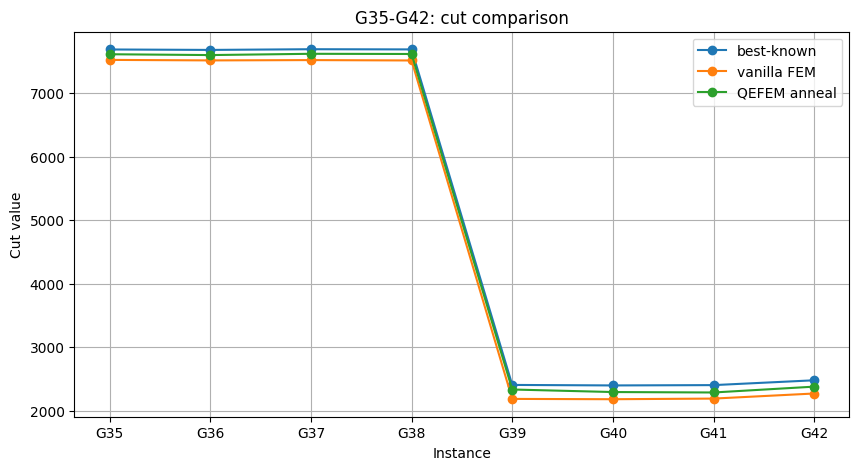

In [113]:
# ----------------------------
# Plot: cut comparison
# ----------------------------
x = np.arange(len(g35_g42_analysis_df))
labels = g35_g42_analysis_df["instance"].tolist()

plt.figure(figsize=(10, 5))
plt.plot(x, g35_g42_analysis_df["best_value"], marker="o", label="best-known")
plt.plot(x, g35_g42_analysis_df["vanilla_cut"], marker="o", label="vanilla FEM")
plt.plot(x, g35_g42_analysis_df["best_cut"], marker="o", label="QEFEM anneal")
plt.xticks(x, labels)
plt.xlabel("Instance")
plt.ylabel("Cut value")
plt.title("G35-G42: cut comparison")
plt.legend()
plt.grid(True)
plt.show()

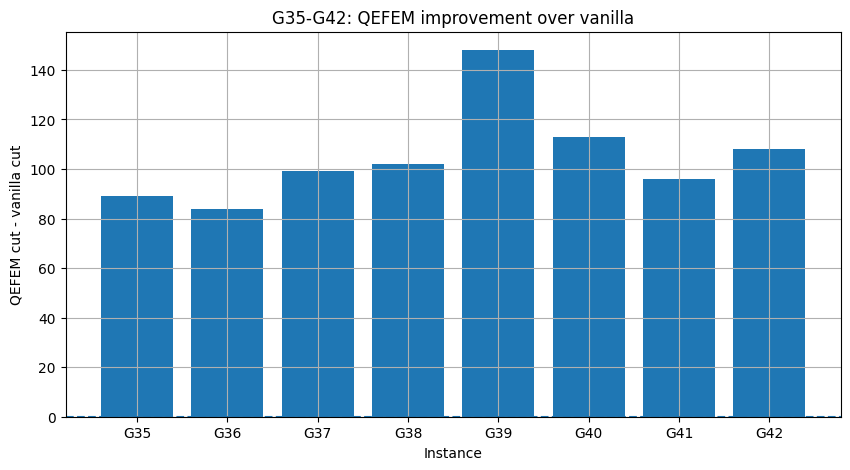

In [114]:
# ----------------------------
# Plot: delta cut vs vanilla
# ----------------------------
plt.figure(figsize=(10, 5))
plt.bar(g35_g42_analysis_df["instance"], g35_g42_analysis_df["delta_cut_vs_vanilla"])
plt.axhline(0, linestyle="--")
plt.xlabel("Instance")
plt.ylabel("QEFEM cut - vanilla cut")
plt.title("G35-G42: QEFEM improvement over vanilla")
plt.grid(True)
plt.show()

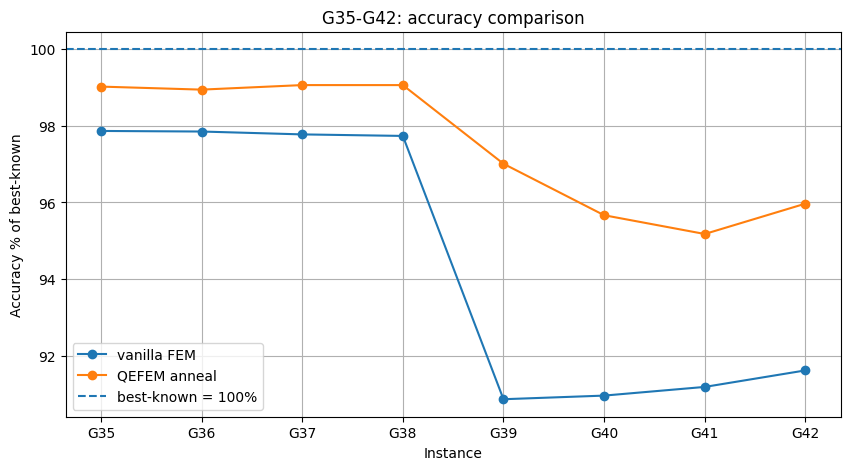

In [115]:
# ----------------------------
# Plot: accuracy comparison
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(x, g35_g42_analysis_df["vanilla_percent_accuracy"], marker="o", label="vanilla FEM")
plt.plot(x, g35_g42_analysis_df["percent_accuracy"], marker="o", label="QEFEM anneal")
plt.axhline(100.0, linestyle="--", label="best-known = 100%")
plt.xticks(x, labels)
plt.xlabel("Instance")
plt.ylabel("Accuracy % of best-known")
plt.title("G35-G42: accuracy comparison")
plt.legend()
plt.grid(True)
plt.show()

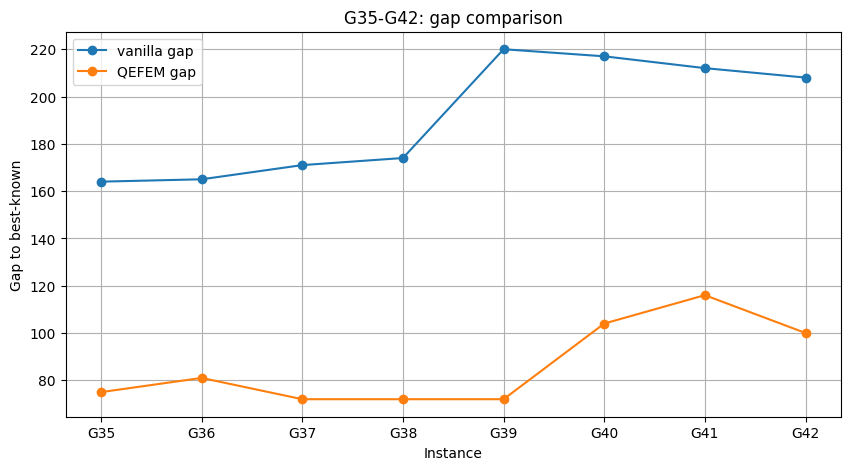

In [116]:
# ----------------------------
# Plot: gap comparison
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(x, g35_g42_analysis_df["vanilla_gap"], marker="o", label="vanilla gap")
plt.plot(x, g35_g42_analysis_df["gap"], marker="o", label="QEFEM gap")
plt.xticks(x, labels)
plt.xlabel("Instance")
plt.ylabel("Gap to best-known")
plt.title("G35-G42: gap comparison")
plt.legend()
plt.grid(True)
plt.show()

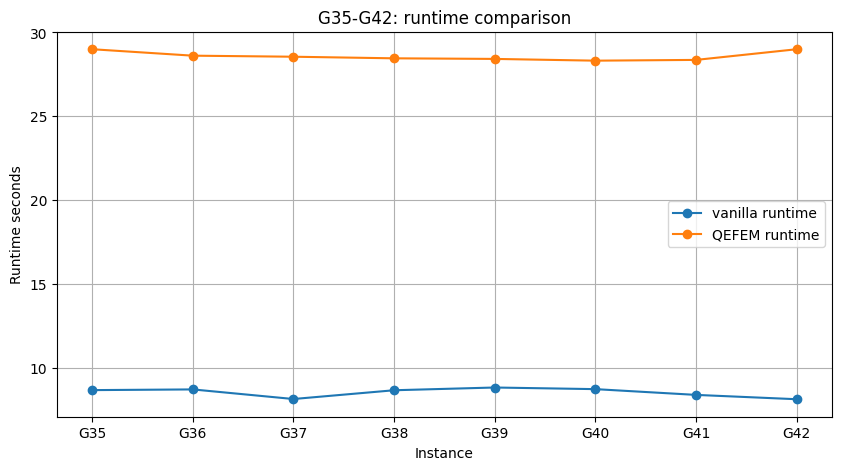

In [117]:
# ----------------------------
# Plot: runtime comparison
# ----------------------------
plt.figure(figsize=(10, 5))
plt.plot(x, g35_g42_analysis_df["vanilla_runtime_sec"], marker="o", label="vanilla runtime")
plt.plot(x, g35_g42_analysis_df["runtime_sec"], marker="o", label="QEFEM runtime")
plt.xticks(x, labels)
plt.xlabel("Instance")
plt.ylabel("Runtime seconds")
plt.title("G35-G42: runtime comparison")
plt.legend()
plt.grid(True)
plt.show()

In [119]:
# ----------------------------
# Final verdict
# ----------------------------
print("\nVerdict:")

if wins == num_instances:
    print(
        f"QEFEM anneal beats vanilla on all {num_instances}/{num_instances} G35-G42 problem-batch instances. "
        "This would be a very strong sign that the method helps exactly where vanilla struggled." 
    )
elif wins > losses:
    print(
        "QEFEM anneal wins more often than it loses on G35-G42. Encouraging."
    )
else:
    print(
        "QEFEM anneal does not clearly beat vanilla on G35-G42. Inspect gamma schedule, rx/rz behavior, and per-instance traces."
    )


Verdict:
QEFEM anneal beats vanilla on all 8/8 G35-G42 problem-batch instances. This would be a very strong sign that the method helps exactly where vanilla struggled.


### Full RUN
G1-G54 ===> all 9 batches

In [121]:
assert "run_qefem_single_gset" in globals(), "Run Cell 18 first. Wrapper function is missing."
# ----------------------------
# Full benchmark target
# ----------------------------
FULL_BENCHMARK_INSTANCES = GSET_ALL_INSTANCES.copy()

print("Full benchmark target:")
print(FULL_BENCHMARK_INSTANCES)
print("Total instances:", len(FULL_BENCHMARK_INSTANCES))


# ----------------------------
# Collect already-computed results
# ----------------------------
existing_result_dfs = []

if "qefem_g1_g10_results_df" in globals():
    print("\nFound existing G1-G10 QEFEM results.")
    existing_result_dfs.append(qefem_g1_g10_results_df.copy())

if "qefem_g35_g42_results_df" in globals():
    print("Found existing G35-G42 QEFEM results.")
    existing_result_dfs.append(qefem_g35_g42_results_df.copy())


if len(existing_result_dfs) > 0:
    qefem_full_results_df = pd.concat(
        existing_result_dfs,
        ignore_index=True,
    )

    # If an instance somehow appears twice, keep the first result.
    # The notebook goblin occasionally duplicates things when humans panic-run cells.
    qefem_full_results_df = (
        qefem_full_results_df
        .drop_duplicates(subset=["instance"], keep="first")
        .reset_index(drop=True)
    )

else:
    qefem_full_results_df = pd.DataFrame()


already_done_instances = set(qefem_full_results_df["instance"]) if len(qefem_full_results_df) > 0 else set()

missing_instances = [
    instance_name
    for instance_name in FULL_BENCHMARK_INSTANCES
    if instance_name not in already_done_instances
]

print("\nAlready done instances:")
print(sorted(already_done_instances, key=lambda x: int(x[1:])))

print("\nMissing instances to run:")
print(missing_instances)

print("\nNumber already done:", len(already_done_instances))
print("Number missing:", len(missing_instances))

Full benchmark target:
['G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'G10', 'G11', 'G12', 'G13', 'G14', 'G15', 'G16', 'G17', 'G18', 'G19', 'G20', 'G21', 'G22', 'G23', 'G24', 'G25', 'G26', 'G27', 'G28', 'G29', 'G30', 'G31', 'G32', 'G33', 'G34', 'G35', 'G36', 'G37', 'G38', 'G39', 'G40', 'G41', 'G42', 'G43', 'G44', 'G45', 'G46', 'G47', 'G48', 'G49', 'G50', 'G51', 'G52', 'G53', 'G54']
Total instances: 54

Found existing G1-G10 QEFEM results.
Found existing G35-G42 QEFEM results.

Already done instances:
['G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'G10', 'G35', 'G36', 'G37', 'G38', 'G39', 'G40', 'G41', 'G42']

Missing instances to run:
['G11', 'G12', 'G13', 'G14', 'G15', 'G16', 'G17', 'G18', 'G19', 'G20', 'G21', 'G22', 'G23', 'G24', 'G25', 'G26', 'G27', 'G28', 'G29', 'G30', 'G31', 'G32', 'G33', 'G34', 'G43', 'G44', 'G45', 'G46', 'G47', 'G48', 'G49', 'G50', 'G51', 'G52', 'G53', 'G54']

Number already done: 18
Number missing: 36


In [122]:
# ----------------------------
# Save starting merged file
# ----------------------------
full_partial_path = OUTPUT_DIR / "qefem_anneal_G1_G54_partial_results.csv"

if len(qefem_full_results_df) > 0:
    qefem_full_results_df = (
        qefem_full_results_df
        .assign(g_index=lambda df: df["instance"].str.replace("G", "", regex=False).astype(int))
        .sort_values("g_index")
        .drop(columns=["g_index"])
        .reset_index(drop=True)
    )

    qefem_full_results_df.to_csv(full_partial_path, index=False)

    print("\nSaved starting merged partial full-results file:")
    print(full_partial_path.resolve())


Saved starting merged partial full-results file:
/Users/ronit/Desktop/QeFEM/main/jupyter/qefem_v1_outputs/qefem_anneal_G1_G54_partial_results.csv


In [123]:
# ----------------------------
# Run missing instances
# ----------------------------
print("\n" + "=" * 80)
print("Starting missing-instance QEFEM full benchmark runs")
print("=" * 80)

for run_idx, instance_name in enumerate(missing_instances, start=1):
    print("\n\n" + "#" * 80)
    print(f"Full G1-G54 missing run {run_idx}/{len(missing_instances)}: {instance_name}")
    print("#" * 80)

    summary, history_df = run_qefem_single_gset(
        instance_name=instance_name,
        gamma_mode="anneal",
        replicas=REPLICAS,
        n_steps=N_STEPS,
        seed=SEED,
        lr=LR,
        beta_min=BETA_MIN,
        beta_max=BETA_MAX,
        gamma_max=GAMMA_MAX,
        gamma_min=GAMMA_MIN,
        R_init=R_INIT,
        theta_center=THETA_CENTER,
        theta_noise=THETA_NOISE,
        print_every=PRINT_EVERY,
        save_history=True,
        output_dir=OUTPUT_DIR,
        device=device,
        dtype=DTYPE,
    )

    # Append new result
    qefem_full_results_df = pd.concat(
        [
            qefem_full_results_df,
            pd.DataFrame([summary]),
        ],
        ignore_index=True,
    )

    # Sort by G index
    qefem_full_results_df = (
        qefem_full_results_df
        .drop_duplicates(subset=["instance"], keep="first")
        .assign(g_index=lambda df: df["instance"].str.replace("G", "", regex=False).astype(int))
        .sort_values("g_index")
        .drop(columns=["g_index"])
        .reset_index(drop=True)
    )

    # Save after every graph, because notebooks die like Victorian children.
    qefem_full_results_df.to_csv(full_partial_path, index=False)

    print("\nCurrent full benchmark progress:")
    print(f"Completed {len(qefem_full_results_df)}/{len(FULL_BENCHMARK_INSTANCES)} instances")

    display(qefem_full_results_df[
        [
            "instance",
            "best_cut",
            "best_value",
            "gap",
            "percent_accuracy",
            "vanilla_cut",
            "delta_cut_vs_vanilla",
            "delta_accuracy_vs_vanilla",
            "runtime_sec",
        ]
    ].tail(10))


Starting missing-instance QEFEM full benchmark runs


################################################################################
Full G1-G54 missing run 1/36: G11
################################################################################
Running QEFEM single instance: G11
gamma_mode: anneal
N: 800
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 564
vanilla cut: 526.0
--------------------------------------------------------------------------------
G11 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=64 | best=64 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.01s
G11 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=26 | best=118 | |rx|=0.0312 | |rz|=0.0000 | elapsed=1.73s
G11 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=-88 | best=118 | |rx|=0.1512 | |rz|=0.0001 | elapsed=3.77s
G11 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=544 | best=544 | |rx|=0.5562 | |rz|=0.0726 | elapsed=5.84s
G11 | step  400/10

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
9,G10,1992.0,2000,8.0,99.600000,1819.0,173.0,8.650000,19.915456
10,G11,556.0,564,8.0,98.581560,526.0,30.0,5.319149,19.825403
11,G35,7612.0,7687,75.0,99.024327,7523.0,89.0,1.157799,29.000239
12,G36,7599.0,7680,81.0,98.945312,7515.0,84.0,1.093750,28.615590
13,G37,7619.0,7691,72.0,99.063841,7520.0,99.0,1.287219,28.553064
14,G38,7616.0,7688,72.0,99.063476,7514.0,102.0,1.326743,28.457916
15,G39,2336.0,2408,72.0,97.009967,2188.0,148.0,6.146179,28.422576
16,G40,2296.0,2400,104.0,95.666667,2183.0,113.0,4.708333,28.318182
17,G41,2289.0,2405,116.0,95.176715,2193.0,96.0,3.991684,28.363543
18,G42,2381.0,2481,100.0,95.969367,2273.0,108.0,4.353083,28.999348




################################################################################
Full G1-G54 missing run 2/36: G12
################################################################################
Running QEFEM single instance: G12
gamma_mode: anneal
N: 800
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 556
vanilla cut: 520.0
--------------------------------------------------------------------------------
G12 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=52 | best=52 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.01s
G12 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=24 | best=94 | |rx|=0.0312 | |rz|=0.0000 | elapsed=1.95s
G12 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=-100 | best=116 | |rx|=0.1512 | |rz|=0.0001 | elapsed=4.00s
G12 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=544 | best=544 | |rx|=0.5519 | |rz|=0.0948 | elapsed=6.01s
G12 | step  400/1000 | beta=4993.69 | gamma=0.6006 | hard_max=550 | bes

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
10,G11,556.0,564,8.0,98.581560,526.0,30.0,5.319149,19.825403
11,G12,550.0,556,6.0,98.920863,520.0,30.0,5.395683,20.725202
12,G35,7612.0,7687,75.0,99.024327,7523.0,89.0,1.157799,29.000239
13,G36,7599.0,7680,81.0,98.945312,7515.0,84.0,1.093750,28.615590
14,G37,7619.0,7691,72.0,99.063841,7520.0,99.0,1.287219,28.553064
15,G38,7616.0,7688,72.0,99.063476,7514.0,102.0,1.326743,28.457916
16,G39,2336.0,2408,72.0,97.009967,2188.0,148.0,6.146179,28.422576
17,G40,2296.0,2400,104.0,95.666667,2183.0,113.0,4.708333,28.318182
18,G41,2289.0,2405,116.0,95.176715,2193.0,96.0,3.991684,28.363543
19,G42,2381.0,2481,100.0,95.969367,2273.0,108.0,4.353083,28.999348




################################################################################
Full G1-G54 missing run 3/36: G13
################################################################################
Running QEFEM single instance: G13
gamma_mode: anneal
N: 800
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 582
vanilla cut: 542.0
--------------------------------------------------------------------------------
G13 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=60 | best=60 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.01s
G13 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=28 | best=106 | |rx|=0.0312 | |rz|=0.0000 | elapsed=1.68s
G13 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=-86 | best=106 | |rx|=0.1512 | |rz|=0.0001 | elapsed=3.69s
G13 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=566 | best=566 | |rx|=0.5490 | |rz|=0.1078 | elapsed=5.80s
G13 | step  400/1000 | beta=4993.69 | gamma=0.6006 | hard_max=580 | bes

...

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
42,G43,6652.0,6660,8.0,99.879880,6514.0,138.0,2.072072,21.725732
43,G44,6638.0,6650,12.0,99.819549,6495.0,143.0,2.150376,21.017268
44,G45,6633.0,6654,21.0,99.684400,6503.0,130.0,1.953712,20.912871
45,G46,6627.0,6649,22.0,99.669123,6492.0,135.0,2.030381,21.105806
46,G47,6638.0,6657,19.0,99.714586,6522.0,116.0,1.742527,20.891538
47,G48,6000.0,6000,0.0,100.000000,5468.0,532.0,8.866667,17.083989
48,G49,6000.0,6000,0.0,100.000000,5514.0,486.0,8.100000,33.784723
49,G50,5852.0,5880,28.0,99.523810,5494.0,358.0,6.088435,35.566553
50,G51,3819.0,3848,29.0,99.246362,3779.0,40.0,1.039501,21.510869
51,G52,3825.0,3851,26.0,99.324851,3779.0,46.0,1.194495,22.059001




################################################################################
Full G1-G54 missing run 35/36: G53
################################################################################
Running QEFEM single instance: G53
gamma_mode: anneal
N: 1000
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 3850
vanilla cut: 3778.0
--------------------------------------------------------------------------------
G53 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=3038 | best=3038 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.02s
G53 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=3019 | best=3165 | |rx|=0.0312 | |rz|=0.0000 | elapsed=1.70s
G53 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=2032 | best=3165 | |rx|=0.1512 | |rz|=0.0001 | elapsed=3.89s
G53 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=3789 | best=3789 | |rx|=0.4195 | |rz|=0.3542 | elapsed=6.10s
G53 | step  400/1000 | beta=4993.69 | gamma=0.6006 | har

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
43,G44,6638.0,6650,12.0,99.819549,6495.0,143.0,2.150376,21.017268
44,G45,6633.0,6654,21.0,99.684400,6503.0,130.0,1.953712,20.912871
45,G46,6627.0,6649,22.0,99.669123,6492.0,135.0,2.030381,21.105806
46,G47,6638.0,6657,19.0,99.714586,6522.0,116.0,1.742527,20.891538
47,G48,6000.0,6000,0.0,100.000000,5468.0,532.0,8.866667,17.083989
48,G49,6000.0,6000,0.0,100.000000,5514.0,486.0,8.100000,33.784723
49,G50,5852.0,5880,28.0,99.523810,5494.0,358.0,6.088435,35.566553
50,G51,3819.0,3848,29.0,99.246362,3779.0,40.0,1.039501,21.510869
51,G52,3825.0,3851,26.0,99.324851,3779.0,46.0,1.194495,22.059001
52,G53,3828.0,3850,22.0,99.428571,3778.0,50.0,1.298701,21.292119




################################################################################
Full G1-G54 missing run 36/36: G54
################################################################################
Running QEFEM single instance: G54
gamma_mode: anneal
N: 1000
replicas: 128
n_steps: 1000
lr: 0.01
beta: 2.0 -> 12500.0
gamma: 1.0 -> 0.0
best-known: 3852
vanilla cut: 3778.0
--------------------------------------------------------------------------------
G54 | step    1/1000 | beta=2.00 | gamma=1.0000 | hard_max=3043 | best=3043 | |rx|=0.0101 | |rz|=0.0001 | elapsed=0.02s
G54 | step  100/1000 | beta=1240.54 | gamma=0.9009 | hard_max=3013 | best=3133 | |rx|=0.0312 | |rz|=0.0000 | elapsed=1.62s
G54 | step  200/1000 | beta=2491.59 | gamma=0.8008 | hard_max=2082 | best=3133 | |rx|=0.1512 | |rz|=0.0001 | elapsed=3.80s
G54 | step  300/1000 | beta=3742.64 | gamma=0.7007 | hard_max=3780 | best=3780 | |rx|=0.4216 | |rz|=0.3509 | elapsed=5.99s
G54 | step  400/1000 | beta=4993.69 | gamma=0.6006 | har

,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
44,G45,6633.0,6654,21.0,99.684400,6503.0,130.0,1.953712,20.912871
45,G46,6627.0,6649,22.0,99.669123,6492.0,135.0,2.030381,21.105806
46,G47,6638.0,6657,19.0,99.714586,6522.0,116.0,1.742527,20.891538
47,G48,6000.0,6000,0.0,100.000000,5468.0,532.0,8.866667,17.083989
48,G49,6000.0,6000,0.0,100.000000,5514.0,486.0,8.100000,33.784723
49,G50,5852.0,5880,28.0,99.523810,5494.0,358.0,6.088435,35.566553
50,G51,3819.0,3848,29.0,99.246362,3779.0,40.0,1.039501,21.510869
51,G52,3825.0,3851,26.0,99.324851,3779.0,46.0,1.194495,22.059001
52,G53,3828.0,3850,22.0,99.428571,3778.0,50.0,1.298701,21.292119
53,G54,3820.0,3852,32.0,99.169263,3778.0,42.0,1.090343,21.248591


In [124]:
# ----------------------------
# Final full result file
# ----------------------------
qefem_full_results_df = (
    qefem_full_results_df
    .drop_duplicates(subset=["instance"], keep="first")
    .assign(g_index=lambda df: df["instance"].str.replace("G", "", regex=False).astype(int))
    .sort_values("g_index")
    .drop(columns=["g_index"])
    .reset_index(drop=True)
)

final_full_path = OUTPUT_DIR / "qefem_anneal_G1_G54_final_results.csv"
qefem_full_results_df.to_csv(final_full_path, index=False)

print("\n" + "=" * 80)
print("Full G1-G54 QEFEM gamma anneal benchmark complete")
print("=" * 80)

display(qefem_full_results_df[
    [
        "instance",
        "best_cut",
        "best_value",
        "gap",
        "percent_accuracy",
        "vanilla_cut",
        "delta_cut_vs_vanilla",
        "delta_accuracy_vs_vanilla",
        "runtime_sec",
    ]
])

print("\nSaved final full G1-G54 results to:")
print(final_full_path.resolve())


Full G1-G54 QEFEM gamma anneal benchmark complete


,instance,best_cut,best_value,gap,percent_accuracy,vanilla_cut,delta_cut_vs_vanilla,delta_accuracy_vs_vanilla,runtime_sec
0,G1,11611.0,11624,13.0,99.888162,11446.0,165.0,1.419477,20.077096
1,G2,11610.0,11620,10.0,99.913941,11435.0,175.0,1.506024,20.023929
2,G3,11610.0,11622,12.0,99.896748,11443.0,167.0,1.436930,19.558286
3,G4,11637.0,11646,9.0,99.922720,11503.0,134.0,1.150610,19.926327
4,G5,11622.0,11631,9.0,99.922621,11450.0,172.0,1.478807,20.084831
5,G6,2173.0,2178,5.0,99.770432,1978.0,195.0,8.953168,19.604576
6,G7,1992.0,2006,14.0,99.302094,1822.0,170.0,8.474576,19.974821
7,G8,1991.0,2005,14.0,99.301746,1856.0,135.0,6.733167,19.874761
8,G9,2041.0,2054,13.0,99.367089,1840.0,201.0,9.785784,19.579863
9,G10,1992.0,2000,8.0,99.600000,1819.0,173.0,8.650000,19.915456



Saved final full G1-G54 results to:
/Users/ronit/Desktop/QeFEM/main/jupyter/qefem_v1_outputs/qefem_anneal_G1_G54_final_results.csv


In [125]:
# ----------------------------
# Basic full-run aggregate summary
# ----------------------------
num_full = len(qefem_full_results_df)

full_wins = int((qefem_full_results_df["delta_cut_vs_vanilla"] > 0).sum())
full_ties = int((qefem_full_results_df["delta_cut_vs_vanilla"] == 0).sum())
full_losses = int((qefem_full_results_df["delta_cut_vs_vanilla"] < 0).sum())

full_mean_delta_cut = float(qefem_full_results_df["delta_cut_vs_vanilla"].mean())
full_mean_delta_accuracy = float(qefem_full_results_df["delta_accuracy_vs_vanilla"].mean())
full_mean_accuracy = float(qefem_full_results_df["percent_accuracy"].mean())
full_mean_gap = float(qefem_full_results_df["gap"].mean())
full_mean_runtime = float(qefem_full_results_df["runtime_sec"].mean())

print("\nFull G1-G54 aggregate summary:")
print("Completed instances:", num_full)
print("Wins vs vanilla:", full_wins)
print("Ties vs vanilla:", full_ties)
print("Losses vs vanilla:", full_losses)
print("Mean delta cut vs vanilla:", full_mean_delta_cut)
print("Mean delta accuracy vs vanilla:", full_mean_delta_accuracy)
print("Mean QEFEM accuracy %:", full_mean_accuracy)
print("Mean QEFEM gap:", full_mean_gap)
print("Mean runtime sec:", full_mean_runtime)

assert num_full == len(FULL_BENCHMARK_INSTANCES), (
    "Full benchmark is incomplete. Some instance escaped the net."
)


Full G1-G54 aggregate summary:
Completed instances: 54
Wins vs vanilla: 54
Ties vs vanilla: 0
Losses vs vanilla: 0
Mean delta cut vs vanilla: 157.22222222222223
Mean delta accuracy vs vanilla: 4.272762509982232
Mean QEFEM accuracy %: 99.01509721290039
Mean QEFEM gap: 31.444444444444443
Mean runtime sec: 24.04027273919847
